<a href="https://colab.research.google.com/github/Alenushka2013/Bank-Marketing-Dataset-Machine-Learning-Project/blob/main/Mid_term_Project_code_eda_experim_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

# **Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any

sns.set_style('whitegrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, root_mean_squared_error, r2_score

from mlxtend.plotting import plot_decision_regions


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Alenushka2013/Bank-Marketing-Dataset-Machine-Learning-Project/refs/heads/main/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Кількість дублікатів
print('Кількість дублікатів в даних', df.duplicated().sum(), '\n')
df[df.duplicated(keep=False)].head(6)

Кількість дублікатів в даних 12 



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Виділення числових та категоріальних колонок
numeric_cols = df.select_dtypes(include='number').columns
categor_cols = df.select_dtypes(include='object').columns[:-1]
print('Кількість числових колонок:', len(numeric_cols))
print('Кількість категоріальних колонок:', len(categor_cols))

Кількість числових колонок: 10
Кількість категоріальних колонок: 10


In [7]:
df.describe(percentiles = [0, 0.03, 0.25, 0.75, 0.98, 1]).round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
0%,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
3%,25.00,23.00,1.00,9.00,0.00,-3.00,92.43,-47.10,0.72,4991.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
98%,62.00,1052.26,11.00,999.00,2.00,1.40,94.46,-30.10,4.97,5228.10


**Спостереження**:

Дані представлені: 20 ознак (10 числовий і 10 категоріальних) + цільова змінна, 41188 спостережень, серед яких 12 дублікатів.

1. Змінна age має цілком правдоподібні значення, варто первірити на викиди, а також поцікавитися з якого віку банки оформлюють депозити.
2. Змінна duration(тривалість останнього контакту в секундах): найбільше значення 4918 секунд віповідає 1.4 годині, таке може бути. Ця змінна не буде використовуватися в фінальній моделі.
3. Змінна campaign(кількість контактів у межах поточної кампанії для цього клієнта): максимальне значення 56, завелике, потрібно перевірити на викиди.
4. Змінна pdays(кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії): значення 999 означає, що клієнт раніше не контактувався і таких значень більшість, можливо потрібно буде перетворити дані, в такому вигляді не завжди підходять для коректного аналізу.
5. Змінна previous(кількість контактів, здійснених до цієї кампанії для цього клієнта): значення від 0 до 7 цілком відповідають контексту.

6. Атрибути соціально-економічного контексту: emp.var.rate,	cons.price.idx,	cons.conf.idx,	euribor3m,	nr.employed в цьому наборі даних демонструють загалом стабільний економічний контекст протягом спостережуваного періоду.

## Аналіз числових ознак

### Аналіз числової ознаки 'age'

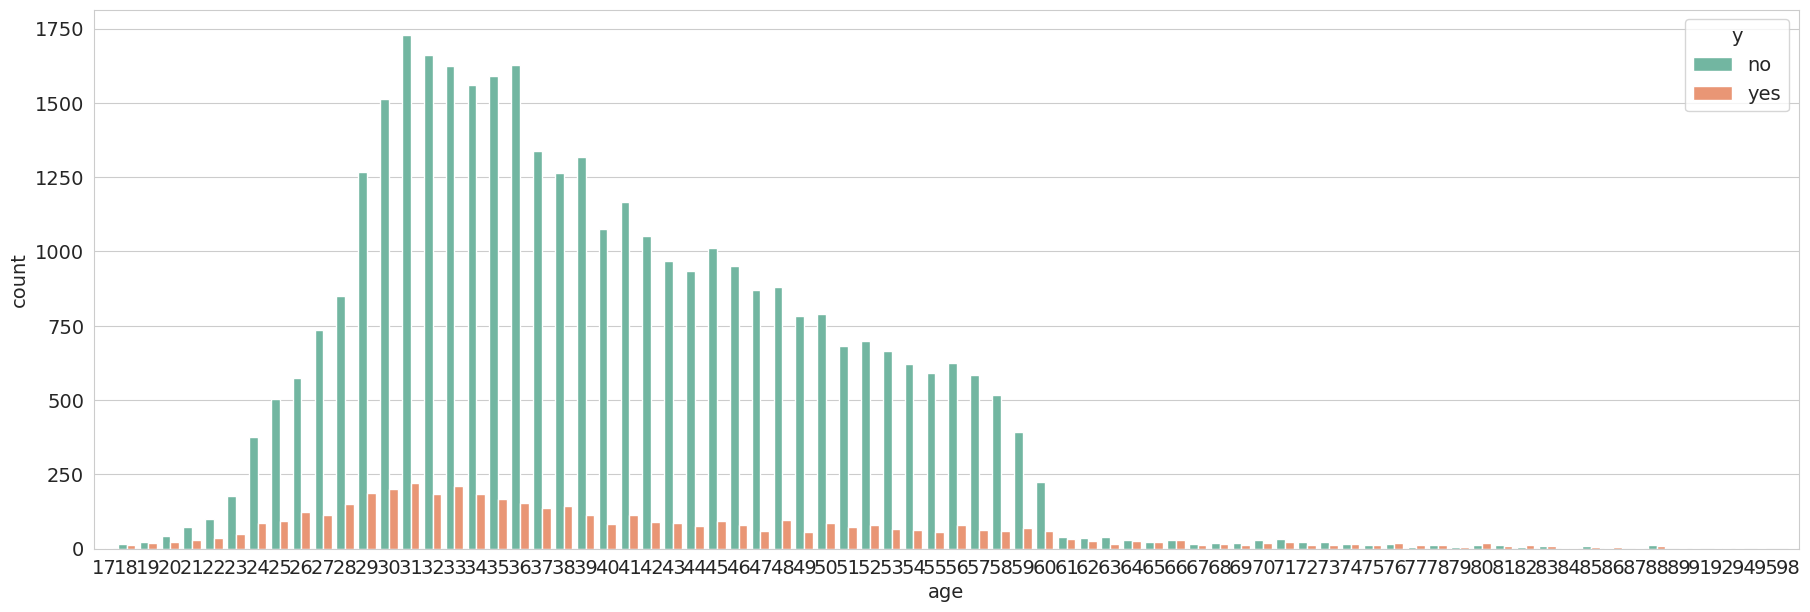

In [8]:
plt.figure(figsize=(22, 7))
sns.countplot(x='age', hue='y', data=df, palette='Set2')
plt.show();

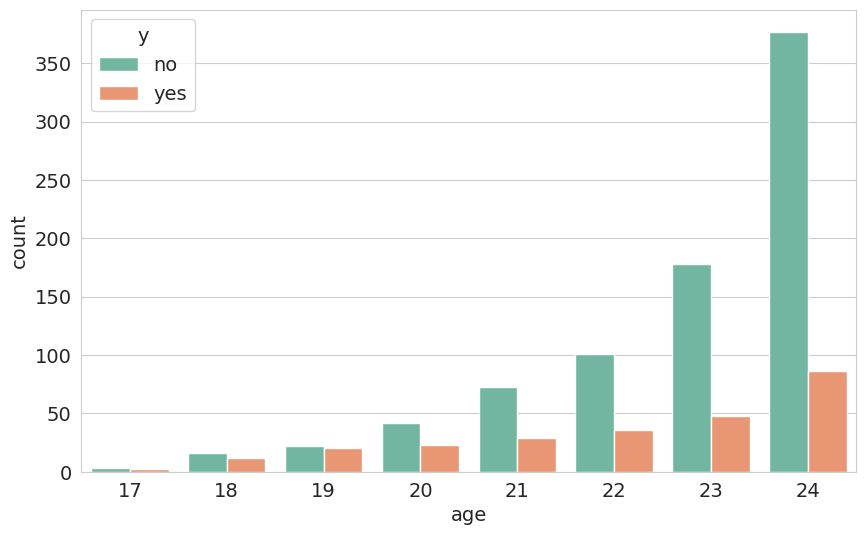

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x='age', hue='y', data=df[df.age < 25], palette='Set2')
plt.show();

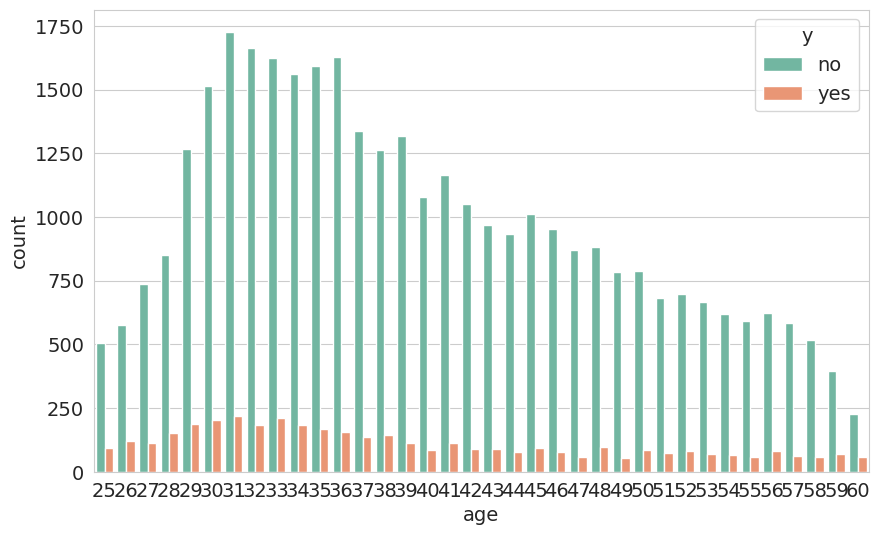

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='age', hue='y', data=df[(df.age >= 25) & (df.age <= 60)], palette='Set2')
plt.show();

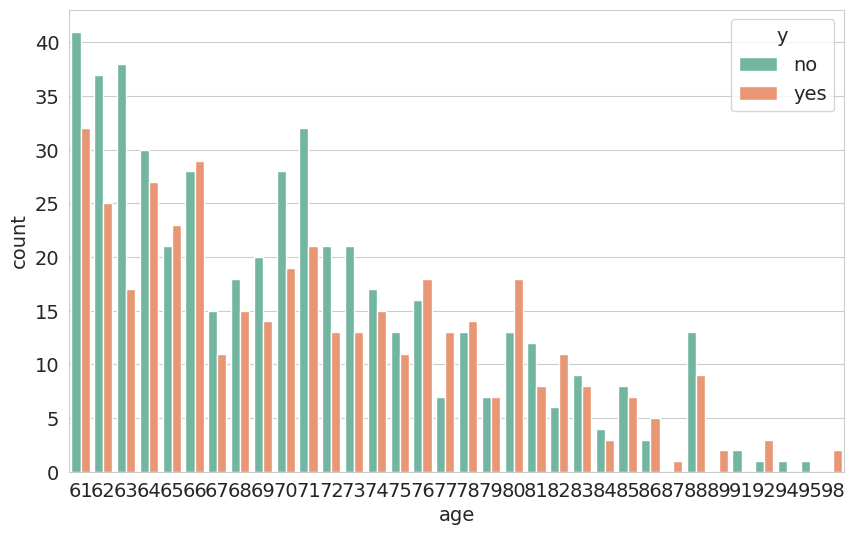

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='age', hue='y', data=df[df.age > 60], palette='Set2')
plt.show();

**Висновки:**

В більшості країн юридичний мінімальний вік для відкриття банківського рахунку становить 18 років. Особи молодші за 18 років можуть відкрити рахунок для неповнолітніх, але з обов'язковою згодою та підписом батьків або опікунів. І таких клієнтів всього 5.

Типові вікові групи

- Молоді люди (18-25 років) зазвичай частіше використовують поточні рахунки для щоденних транзакцій, а не довгострокові депозити, оскільки їхній пріоритет — гнучкість, а не заощадження.
- Дорослі в робочому віці (25-60 років): Ця група накопичує заощадження і шукає можливості для їхнього зберігання та примноження. Вони є найбільшою категорією вкладників. Саме на цю категорію і були розраховані маркетингові компанії.
- Люди пенсійного віку (60+): Клієнти цієї вікової групи часто мають значні заощадження, які вони отримують з пенсій або накопичень. Вони зацікавлені в консервативних фінансових інструментах з гарантованим доходом, тому депозити для них є дуже популярним продуктом.


Чи потрібно прибирати значення, які вважаються викидами? В даному випадку розподіл даних для клієнтів старших 70 років є більш-менш рівномірним і видалення таких даних забере 200 із майже 4.5 тисяч позитивних результатів і стільки ж негативних. В цілому розподіл цільової змінної майже не зміниться. Треба буде поекспериментувати.  




### Аналіз числової ознаки 'duration'

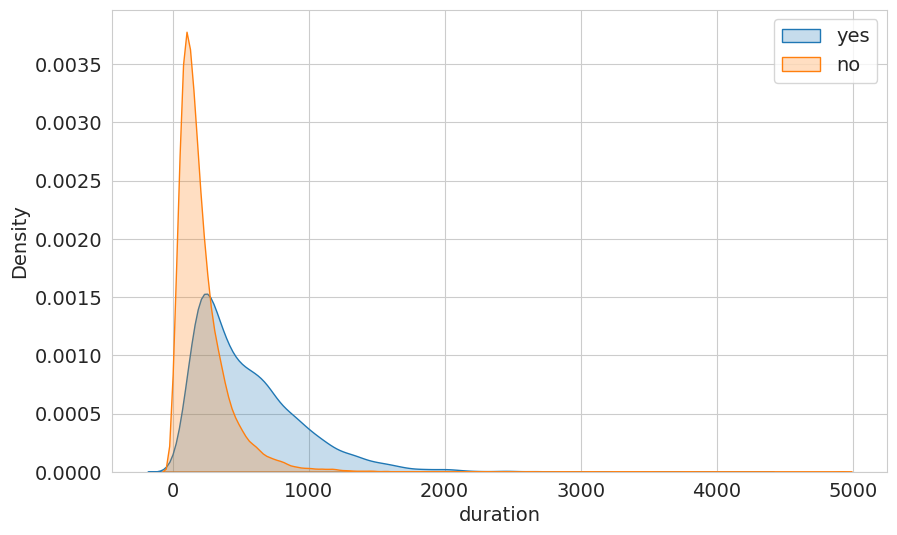

In [12]:
sns.kdeplot(data=df[df['y'] == 'yes'], x='duration', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='duration', label='no', fill=True)
plt.legend()
plt.show()

**Висновки:**

- Зміщення вліво для “no”: більшість відмов від депозиту (оранжева лінія) відбувається при дуже коротких дзвінках (часто до 200 секунд).

- “Хвіст” для “yes”: клієнти, які погодилися (синя лінія), мають розподіл, що тягнеться далі вправо — тобто в них дзвінки тривають довше, іноді до кількох тисяч секунд.

- Розділення розподілів: чітко видно, що короткі дзвінки майже завжди ведуть до “no”, а ймовірність “yes” суттєво зростає зі збільшенням тривалості розмови.

- Змінна duration є сильним предиктором результату кампанії. Саме тому її не варто використовувати у фінальній моделі прогнозування — адже значення відоме тільки після дзвінка, а тоді й результат вже відомий.

### Аналіз числової ознаки 'campaign'

In [13]:
# відфільтруємо потрібний діапазон
subset = df[(df.campaign >= 1) & (df.campaign <= 60)]

# рахуємо кількість і одразу розкладаємо по колонках y
table = (subset.groupby(['campaign', 'y'])
    .size()
    .unstack(fill_value=0)
)

# перейменування колонок
table = table.rename(columns={'no': 'y_no', 'yes': 'y_yes'})

# сумарна кількість
table['count'] = table['y_no'] + table['y_yes']

# відсоток "yes" (y = yes)
table['percent_yes'] = round(table['y_yes'] / table['count'] * 100, 1)

print(table[table.percent_yes > 0])

y          y_no  y_yes  count  percent_yes
campaign                                  
1         15342   2300  17642         13.0
2          9359   1211  10570         11.5
3          4767    574   5341         10.7
4          2402    249   2651          9.4
5          1479    120   1599          7.5
6           904     75    979          7.7
7           591     38    629          6.0
8           383     17    400          4.2
9           266     17    283          6.0
10          213     12    225          5.3
11          165     12    177          6.8
12          122      3    125          2.4
13           88      4     92          4.3
14           68      1     69          1.4
15           49      2     51          3.9
17           54      4     58          6.9
23           15      1     16          6.2


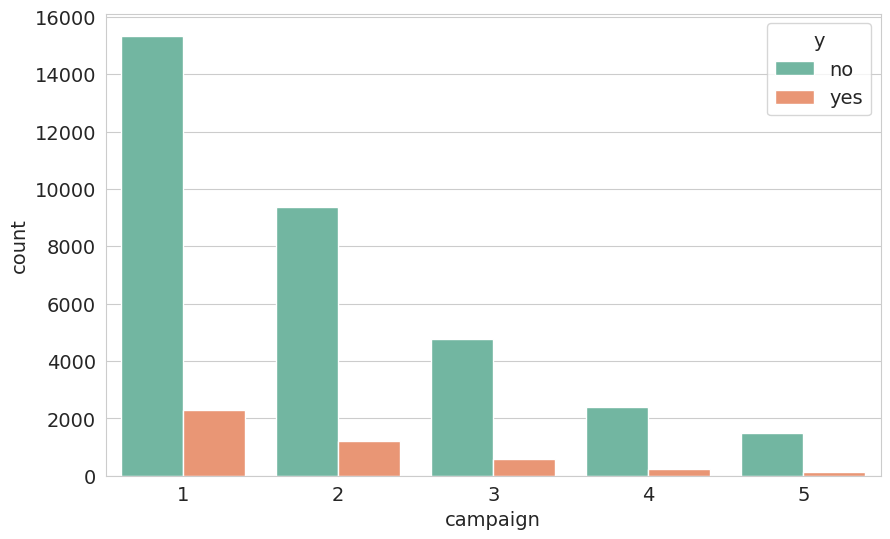

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='campaign', hue='y', data=df[df.campaign < 6], palette='Set2')
plt.show();

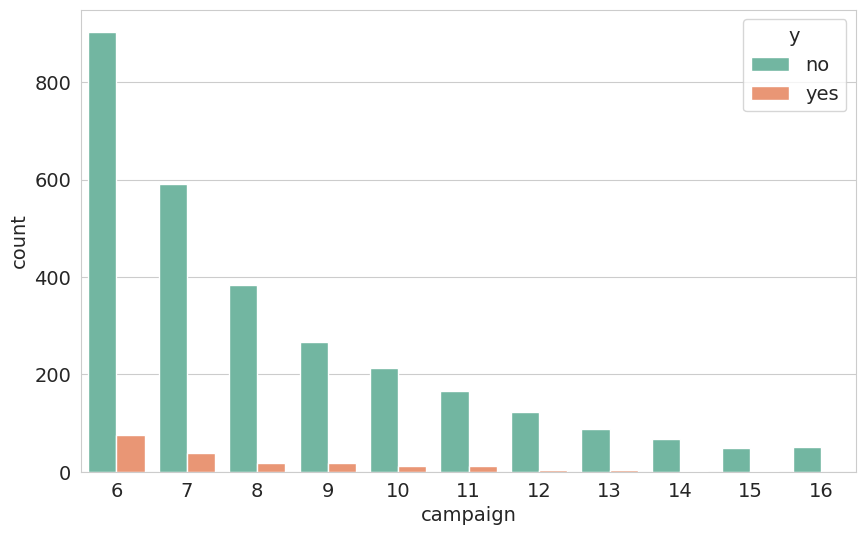

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x='campaign', hue='y', data=df[(df.campaign >= 6) & (df.campaign <= 16)], palette='Set2')
plt.show();

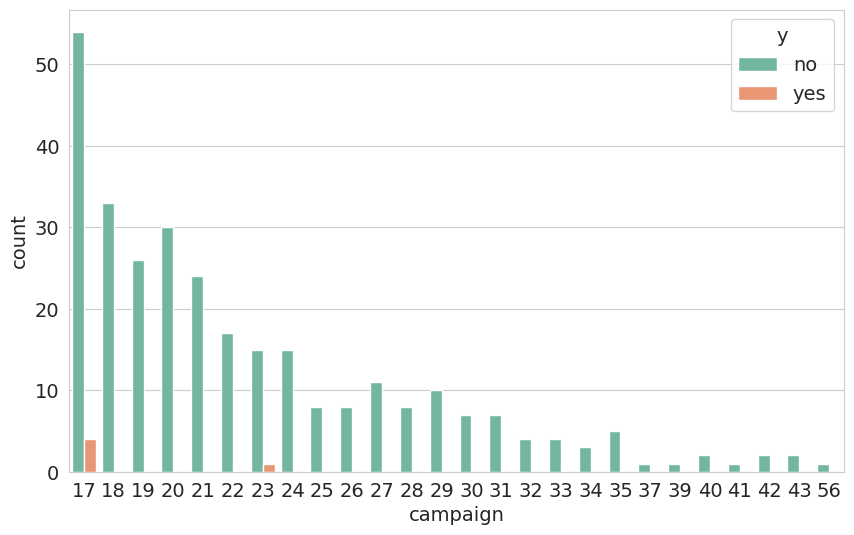

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x='campaign', hue='y', data=df[df.campaign > 16], palette='Set2')
plt.show();

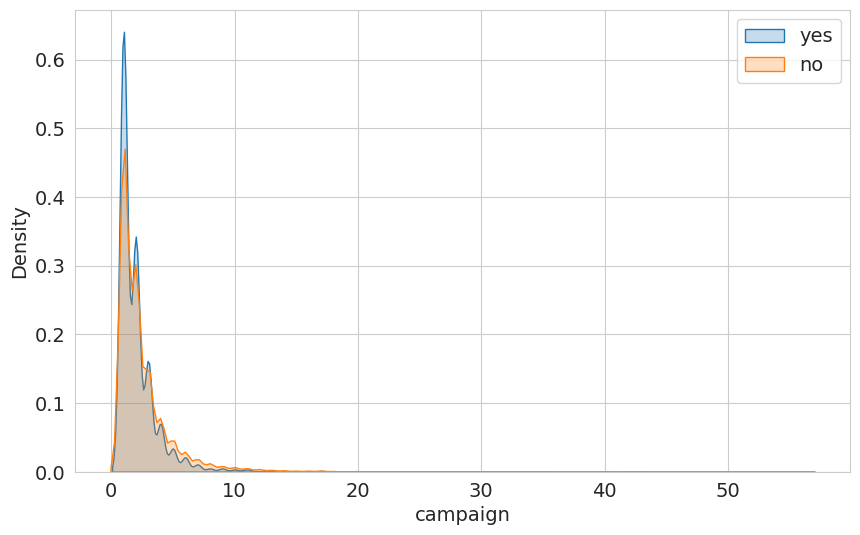

In [17]:
sns.kdeplot(data=df[df['y'] == 'yes'], x='campaign', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='campaign', label='no', fill=True)
plt.legend()
plt.show()

**Висновки:**

- Більшість клієнтів мають дуже малу кількість контактів — пік на 1–2 дзвінках (більше половини даних).

- При зростанні кількості контактів (5, 10, 20…) густина швидко падає майже до нуля. Тобто довгі кампанії (30–50 контактів) зустрічаються рідко.

- Розподіли для yes та no сильно перекриваються, але є тенденція: для клієнтів, які підписали депозит (yes), більш імовірні менші значення campaign. Це логічно: якщо клієнт погоджується на початкових етапах, немає потреби дзвонити десятки разів.

### Аналіз числової ознаки 'previous'

In [18]:
df.previous.value_counts().sort_index().to_frame().T

previous,0,1,2,3,4,5,6,7
count,35563,4561,754,216,70,18,5,1


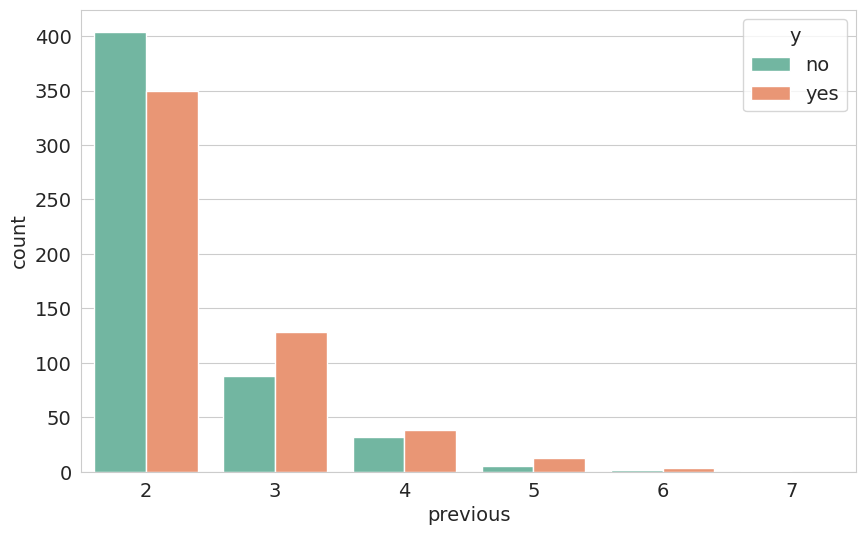

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='previous', hue='y', data=df[df.previous > 1], palette='Set2')
plt.show();

**Спостереження**:

Клієнти, з якими були контакти до поточної кампанії охочіше підписують строковий депозит.   

### Аналіз числової ознаки 'pdays'

In [20]:
df.pdays.value_counts().sort_index().to_frame().T

pdays,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,25,26,27,999
count,15,26,61,439,118,46,412,60,18,64,...,8,7,3,1,2,3,1,1,1,39673


In [21]:
table = (df.groupby(['pdays', 'y'])
    .size()
    .unstack(fill_value=0)
)

# перейменування колонок
table = table.rename(columns={'no': 'y_no', 'yes': 'y_yes'})

# сумарна кількість
table['count'] = table['y_no'] + table['y_yes']

# відсоток "yes" (y = yes)
table['percent_yes'] = round(table['y_yes'] / table['count'] * 100, 1)

print(table[table.percent_yes > 0])

y       y_no  y_yes  count  percent_yes
pdays                                  
0          5     10     15         66.7
1         18      8     26         30.8
2         24     37     61         60.7
3        141    298    439         67.9
4         55     63    118         53.4
5         17     29     46         63.0
6        123    289    412         70.1
7         20     40     60         66.7
8          6     12     18         66.7
9         29     35     64         54.7
10        22     30     52         57.7
11        13     15     28         53.6
12        32     26     58         44.8
13         8     28     36         77.8
14         9     11     20         55.0
15         8     16     24         66.7
16         5      6     11         54.5
17         6      2      8         25.0
18         3      4      7         57.1
19         2      1      3         33.3
21         0      2      2        100.0
22         1      2      3         66.7
25         0      1      1        100.0


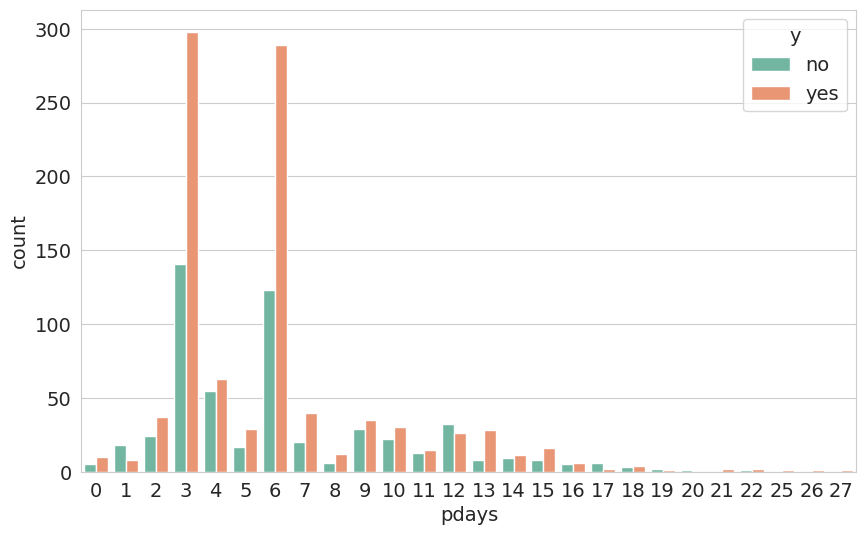

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(x='pdays', hue='y', data=df[df.pdays != 999], palette='Set2')
plt.show();

**Висновки:**

Більшість значеннь змінної 999, тобто клієнт раніше, у попередній кампанії, не контактував.

Якщо клієнт контактував у попередній компанії, то спостерігається вищій відсоток підписаних депозитів.



### Аналіз числових ознак 'emp.var.rate',	'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'

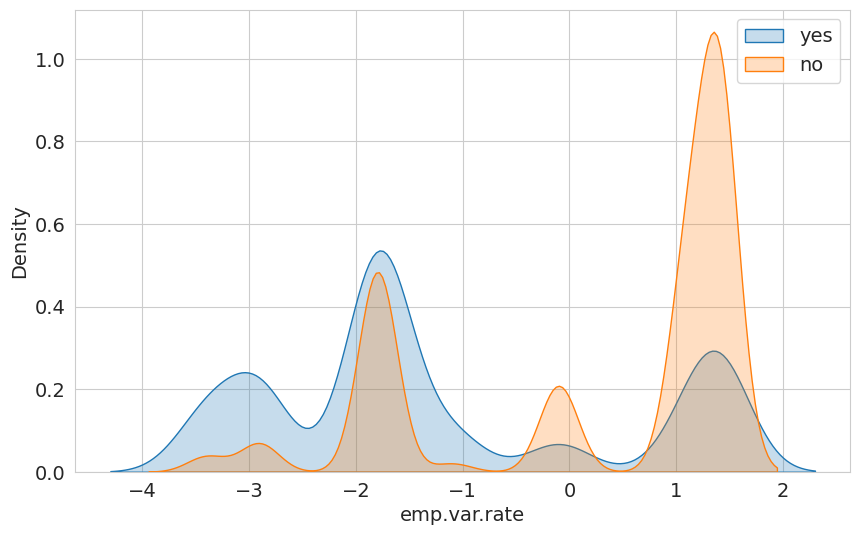

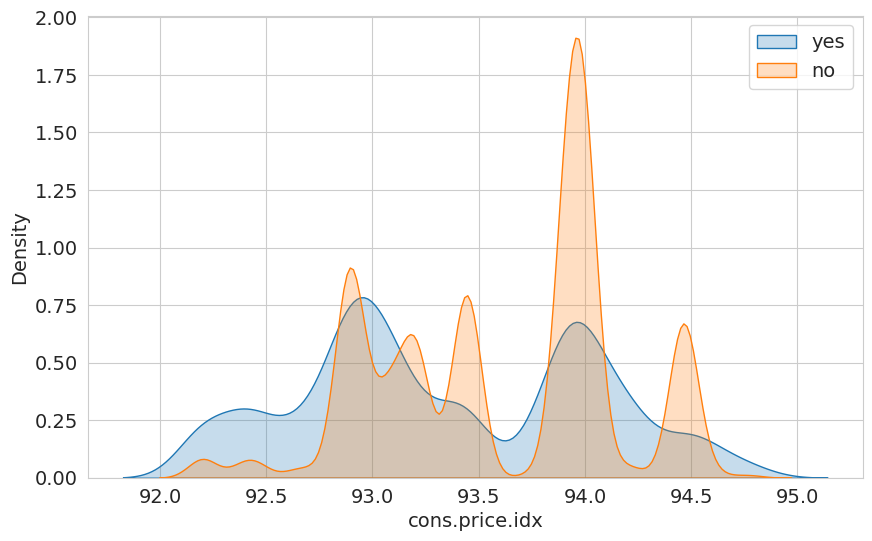

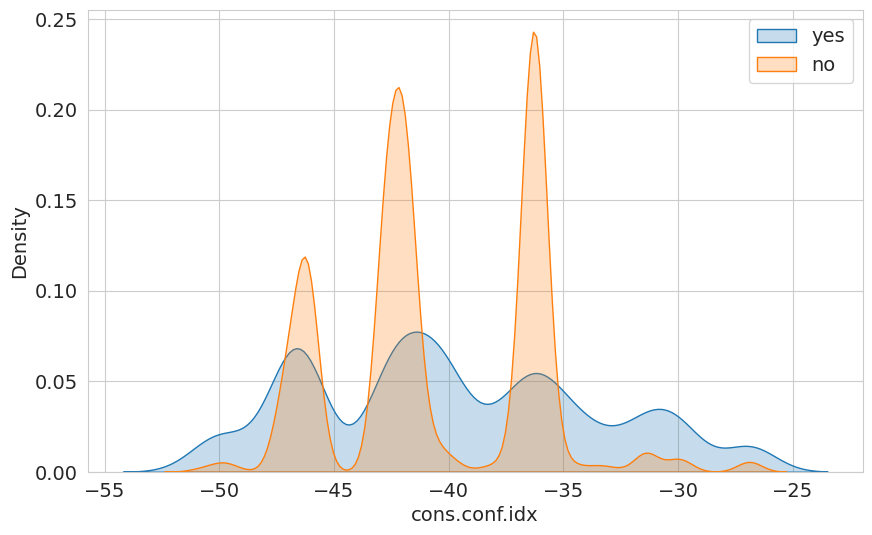

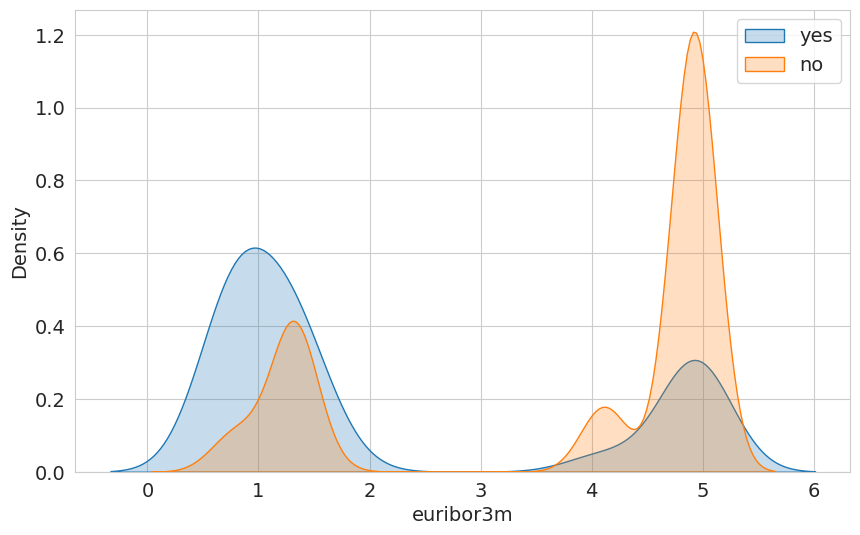

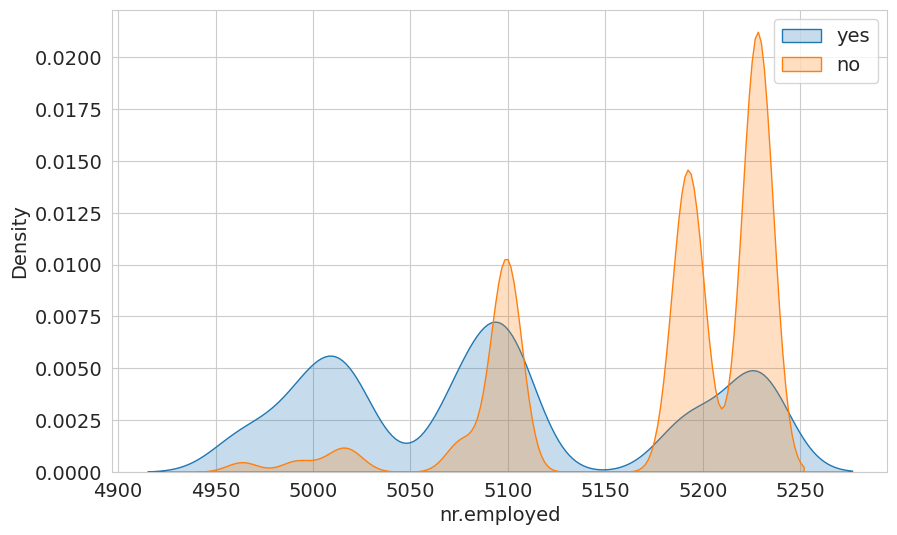

In [23]:
for col in ['emp.var.rate',	'cons.price.idx','cons.conf.idx', 'euribor3m', 'nr.employed']:
  # sns.countplot(x=col, hue='y', data=df, palette='Set2')
  # plt.show()

  sns.kdeplot(data=df[df['y'] == 'yes'], x=col, label='yes', fill=True)
  sns.kdeplot(data=df[df['y'] == 'no'], x=col, label='no', fill=True)
  plt.legend()
  plt.show()

**Спостереження**:

*emp.var.rate* (темп зміни зайнятості):

- клієнти, що погодилися підписати депозит ("yes"), частіше зустрічаються при негативних значеннях emp.var.rate (≈ від -3 до -1).

- ті, хто відповів "no", значно більше сконцентровані навколо позитивних значень (~1–1.5).

*cons.price.idx* (індекс споживчих цін)

- для клієнтів з "yes" розподіл більш розмазаний по діапазону [92–95], тоді як для "no" видно чіткі піки, особливо біля 94.0.

*cons.conf.idx *(індекс довіри споживачів)

- "no" має яскраво виражені піки навколо -36, -41, -46.

- "yes" більш рівномірно розподілені і помітно більше у зоні нижчої довіри (≈ -50).

*euribor3m *(Ставка Euribor на 3 місяці)

- на графіку помітно, що більшість успішних угод 'yes' була укладена, коли ставка Euribor була високою (близько 5%).
- у період низьких ставок кількість успішних угод значно менша.

Це має сенс, адже високі процентні ставки роблять строкові депозити більш привабливими для клієнтів, оскільки вони отримують вищий дохід.

*nr.employed* (кількість працевлаштованих осіб)

- найбільший пік відмов 'no' припадає на період з високою кількістю працевлаштованих осіб.

-  найбільший пік успішних угод 'yes' припадає на період з нижчою кількістю працевлаштованих осіб.


## Розподіл цільової змінної

In [24]:
df.y.value_counts(normalize = True).round(3)* 100

,proportion
y,
no,88.7
yes,11.3


In [25]:
# Створення нової  числової колонки для категоріальної змінної
df['y_num'] = df['y'].map({'no': 0, 'yes': 1})

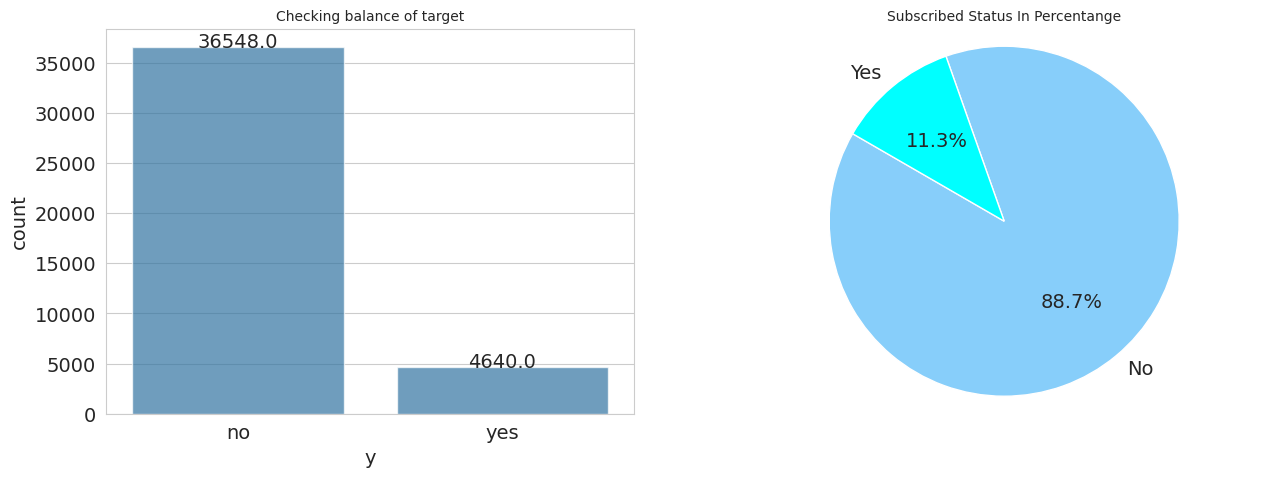

In [26]:
plt.rcParams['figure.figsize']=15,5
plt.subplot(121)
plt.title('Checking balance of target', fontsize=10)
s = sns.countplot(x="y", data=df, alpha=0.7)
for p in s.patches:
    s.annotate(format(p.get_height(), '.1f'),
               (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 4),
                textcoords = 'offset points')


ax = plt.subplot(122)
mush_classpie = df['y'].value_counts()
mush_size = mush_classpie.values.tolist()
mush_types = mush_classpie.axes[0].tolist()
mush_labels = 'No', 'Yes'
colors = ['lightskyblue', '#00FFFF']
plt.title('Subscribed Status In Percentange', fontsize=10)
patches, texts, autotexts = plt.pie(mush_size, labels=mush_labels,  colors=colors,
        autopct='%1.1f%%',  startangle=150)
plt.axis('equal')
plt.show();

**Спостереження**:

Розподіл цільової змінної "no" - 88.7%, "yes" - 11.3%, майже 8:1, свідчить про незбалансованість класів. Переважна більшість клієнтів не оформлює депозит. Це важливо враховувати при побудові моделі та слід розглянути підходи, які працюють для незбалансованих даних:
 - Oversampling (збільшення кількості "yes" спостережень),
 - Undersampling (зменшення кількості "no" спостережень).

## Матриця кореляції

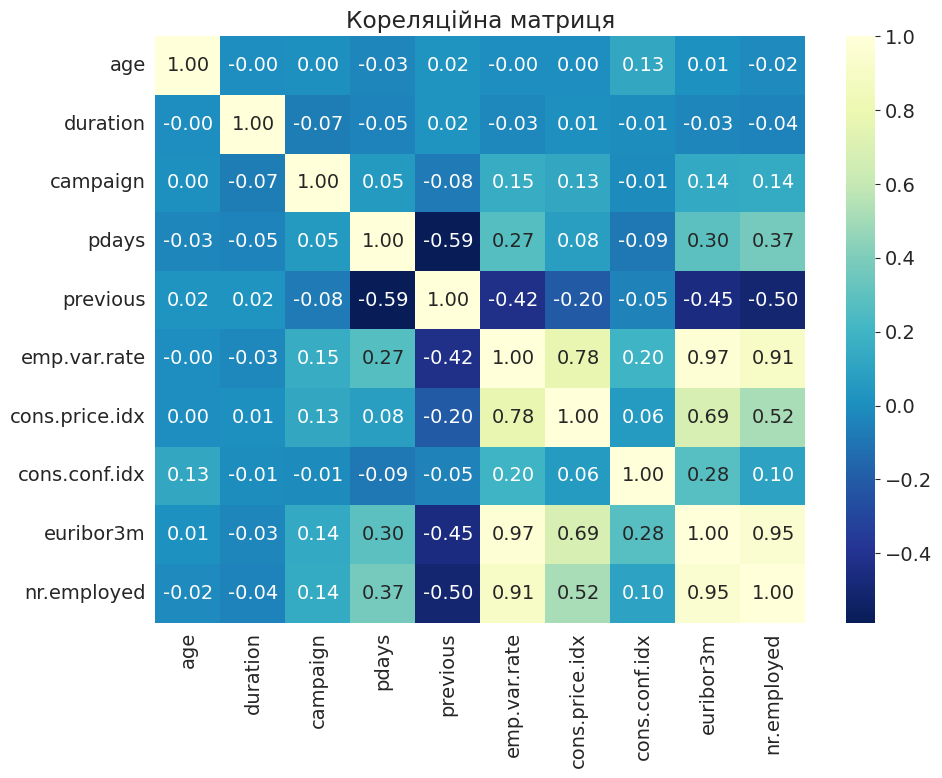

In [27]:
# Вибір числових стовбців для побудови кореляційної матриці
corr_cols = df.select_dtypes(include='number').columns

# Теплова карта кореляційної матриці
plt.figure(figsize=(10, 8)) # Розмір графіка: ширина=10, висота=8
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,             # показувати значення
    fmt=".2f",              # два знаки після коми
    cmap="YlGnBu_r")        # колірна гама: Yellow-Green-Blue
plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

In [28]:
df[corr_cols].corr().y_num.sort_values()[:-1]

,y_num
nr.employed,-0.354678
pdays,-0.324914
euribor3m,-0.307771
emp.var.rate,-0.298334
cons.price.idx,-0.136211
campaign,-0.066357
age,0.030399
cons.conf.idx,0.054878
previous,0.230181
duration,0.405274


**Спостереження:**

*Сильна негативна кореляція*

nr.employed (-0.354669): Найсильніша негативна кореляція. Це говорить про те, що чим менше людей працює в цьому районі, тим більша ймовірність успішного результату (y_num). Це може свідчити про те, що люди, які є безробітними або проживають у районах з високим рівнем безробіття, більш сприйнятливі до кампанії.

pdays (-0.324948): Сильний негативний зв'язок. pdays likely представляє кількість днів з моменту останнього контакту. Насправді не є коректним, спочатку потрібно розібратися зі значеннями 999.

euribor3m (-0.307740): 3-місячна ставка Euribor є еталонною процентною ставкою. Негативна кореляція говорить про те, що нижча процентна ставка пов'язана з більшою ймовірністю успішного результату.

*Слабша негативна кореляція*

emp.var.rate (-0.298289): Коефіцієнт зміни зайнятості. Негативна кореляція вказує на те, що зі зниженням рівня зайнятості ймовірність успіху зростає. Це узгоджується з nr.employed.

cons.price.idx (-0.136134): Індекс споживчих цін. Дуже слабка негативна кореляція свідчить про те, що нижчий ІСЦ (нижчі ціни) дуже слабо пов'язаний з вищою ймовірністю успіху.

campaign (-0.066361): Кількість контактів, здійснених під час кампанії. Дуже слабка негативна кореляція свідчить про те, що більша кількість контактів дещо пов'язана з меншою ймовірністю успішного результату. Це важливий висновок, який може свідчити про те, що повторні дзвінки є неефективними або навіть контрпродуктивними.

*Позитивна кореляція*

age (0.030381): Дуже слабка позитивна кореляція. Це означає, що дещо вищий вік дуже слабо пов'язаний з вищою ймовірністю успішного результату.

cons.conf.idx (0.054802): Індекс довіри споживачів. Дуже слабкий позитивний зв'язок свідчить про те, що вища довіра споживачів незначно пов'язана з вищою ймовірністю успіху.

previous (0,230202): Кількість попередніх контактів. Помірна позитивна кореляція вказує на те, що більша кількість попередніх контактів пов'язана з вищою ймовірністю успішного результату. Це протилежність змінній кампанії та є ключовим висновком. Це говорить про те, що попередні успішні взаємодії або історія мають більше значення, ніж кількість дзвінків у поточній кампанії.

duration (0,405297): Тривалість останнього контакту в секундах. Це найсильніша позитивна кореляція. Це критично важливий висновок, оскільки він говорить про те, що чим довше триває дзвінок, тим більша ймовірність того, що він призведе до успішного результату. Ця змінна є витіком даних і використовуватися в фінальній моделі не буде.


## Аналіз категоріальних ознак

In [29]:
categorical_columns = df.iloc[:-1, :].select_dtypes(include=['object']).columns.tolist()

frames = []

for column in categorical_columns:
    unique_values = df[column].unique()
    # Create a DataFrame for each column's unique values
    temp_df = pd.DataFrame({'Column Name': column, 'Unique Values': [unique_values], 'Count Unique Values': len(unique_values)})
    frames.append(temp_df)

# Concatenate all DataFrames in the list
unique_values_df = pd.concat(frames, ignore_index=True)
pd.set_option('display.max_colwidth', None)

display(unique_values_df)

,Column Name,Unique Values,Count Unique Values
0,job,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]",12
1,marital,"[married, single, divorced, unknown]",4
2,education,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]",8
3,default,"[no, unknown, yes]",3
4,housing,"[no, yes, unknown]",3
5,loan,"[no, yes, unknown]",3
6,contact,"[telephone, cellular]",2
7,month,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]",10
8,day_of_week,"[mon, tue, wed, thu, fri]",5
9,poutcome,"[nonexistent, failure, success]",3


In [30]:
# Задаємо список колонок для аналізу
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Обчислення кількості значень 'unknown'
unknown_count = (df[unknown_cols] == 'unknown').sum()

# Обчислення відсотка значень 'unknown'
total_rows = len(df)
unknown_percent = (unknown_count / total_rows) * 100

# Створення таблиці-звіту
unknown_report = pd.DataFrame({
    'Unknown Count': unknown_count,
    'Unknown Percentage (%)': unknown_percent.round(2)
})

# Виведення звіту
display(unknown_report)


,Unknown Count,Unknown Percentage (%)
job,330,0.80
marital,80,0.19
education,1731,4.20
default,8597,20.87
housing,990,2.40
loan,990,2.40


**Спостереження**:

В наборі даних десять категоріальних ознак, які мають від 2 до 12 різних значень.

Ознаки job, marital, education, default, housing, loan містять пропуски, які позначені як 'unknown'.

Для таких колонок, як job, marital, housing, та loan, частка пропусків не є критичною. Можна замінити значення "unknown" модою. Це збереже більшу частину даних і не спотворить загальний розподіл.

Змінна education має 4.2% пропусків. Можливі варіанти заміни:
- використати алгоритми машинного навчання, щоб передбачити пропущене значення на основі інших ознак,
- заміна на категорію "невизначеність", щоб моделі могли відізняти цей тип від інших ознак,
- заміна на моду.

Змінна default має найбільшу кількість пропусків 20.87%. Заміна майже п'ятої частини значень може привести до спотворення даних. Можна залишити 'unknown' як окрему категорію або замінити на моду і додати індикатор.



In [31]:
def categor_plots(df, col):
  # Create a figure with two subplots in one row
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

  # ---- First plot: barplot ----
  #col = 'education'
  sns.barplot(
      x=col,
      y='y_num',
      data=df,
      estimator=np.mean,
      hue=col,
      dodge=False,
      palette='Set2',
      legend=False,
      ax=axes[0]
  )
  axes[0].set_ylabel('Class 1 probability')

  # FIX: Get both tick positions and labels and then set them
  tick_positions = axes[0].get_xticks()
  labels_to_rotate = [l.get_text() for l in axes[0].get_xticklabels()]

  axes[0].set_xticks(tick_positions)
  axes[0].set_xticklabels(labels_to_rotate, rotation=45)

  axes[0].set_title(f'Share of target variable by category {col}')

  # ---- Second plot: countplot ----
  sns.countplot(
      x=col,
      hue='y_num',
      data=df,
      ax=axes[1],
      palette='Set2'
  )
  axes[1].set_title(f'Distribution of {col}')
  axes[1].set_xlabel(col)
  axes[1].set_ylabel('Count')
  axes[1].legend(title='Subscribed to Term Deposit', loc='upper right')
  axes[1].tick_params(axis='x', rotation=45)

  # Adjust plot spacing
  plt.tight_layout()

  # Show the combined figure
  plt.show()

In [32]:
def categor_table_report(df, col, y):

  # Таблиця з кількістю
  counts_table = pd.crosstab(df[col], df[y])

  # Таблиця з відсотками
  percentage_table = pd.crosstab(df[col], df[y], normalize='index') * 100

  # Об'єднання таблиць
  percentage_table = percentage_table.rename(columns={'no': 'no_pct', 'yes': 'yes_pct'})

  # З'єднання таблиць
  combined_table = counts_table.join(percentage_table)

  display(combined_table.sort_values('yes_pct', ascending=False))

### Аналіз категоріальної ознаки 'job'

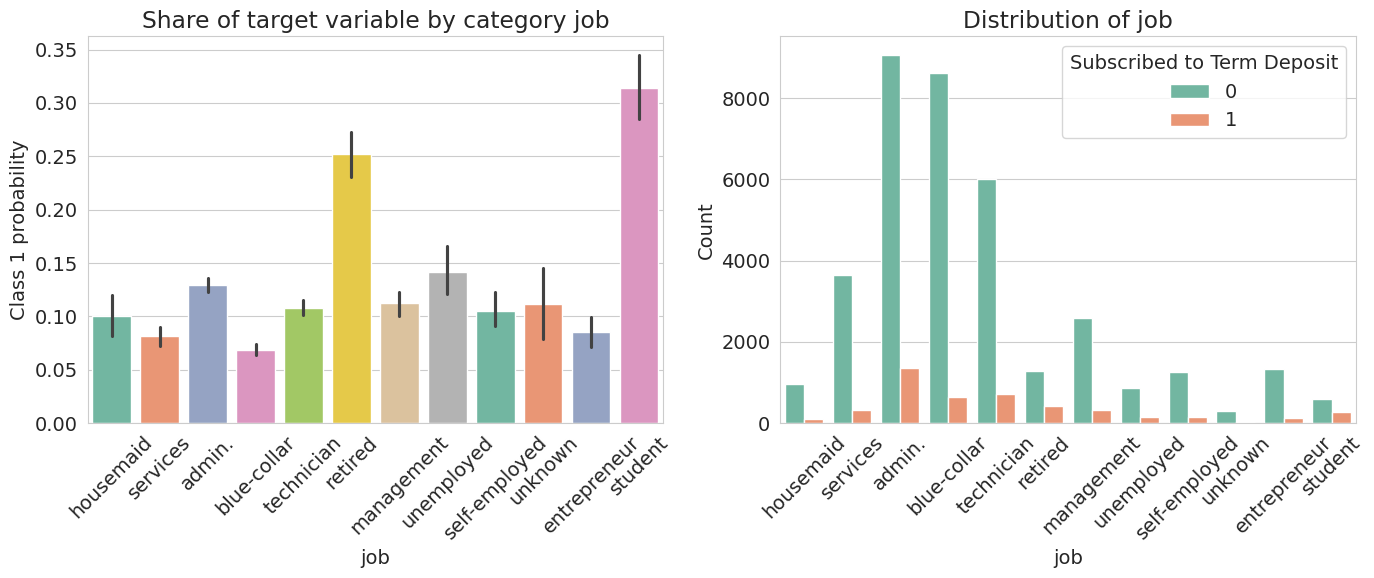

y,no,yes,no_pct,yes_pct
job,,,,
student,600,275,68.571429,31.428571
retired,1286,434,74.767442,25.232558
unemployed,870,144,85.798817,14.201183
admin.,9070,1352,87.027442,12.972558
management,2596,328,88.782490,11.217510
unknown,293,37,88.787879,11.212121
technician,6013,730,89.173958,10.826042
self-employed,1272,149,89.514426,10.485574
housemaid,954,106,90.000000,10.000000


In [33]:
categor_plots(df, 'job')
categor_table_report(df, 'job', 'y')

**Спостереження**:

Найуспішніші категорії:

Student (Студенти): Мають найвищий відсоток успіху — 31.43%. Це може бути пов'язано з тим, що студенти шукають надійні способи заощадження або що банк пропонував їм спеціальні умови.

Retired (Пенсіонери): відсоток успіху 25.23%. Це очікувано, оскільки пенсіонери часто шукають стабільні та безпечні інструменти для збереження своїх заощаджень.

Найменш успішні категорії:

Blue-collar (Сині комірці): Мають найнижчий відсоток успіху — лише 6.89%. Це може свідчити про те, що ця група менш зацікавлена в таких продуктах або не має достатніх коштів для їх оформлення.

Entrepreneur (Підприємці): Ця група також має низький відсоток успіху — 8.52%. Це може бути пов'язано з тим, що вони віддають перевагу інвестуванню своїх коштів у власний бізнес, а не в банківські депозити.

Змінна job є дуже інформативною. Її можна використовувати як важливу ознаку для моделі, оскільки вона дозволяє виявити значні відмінності в поведінці клієнтів.

### Аналіз категоріальної ознаки 'marital'

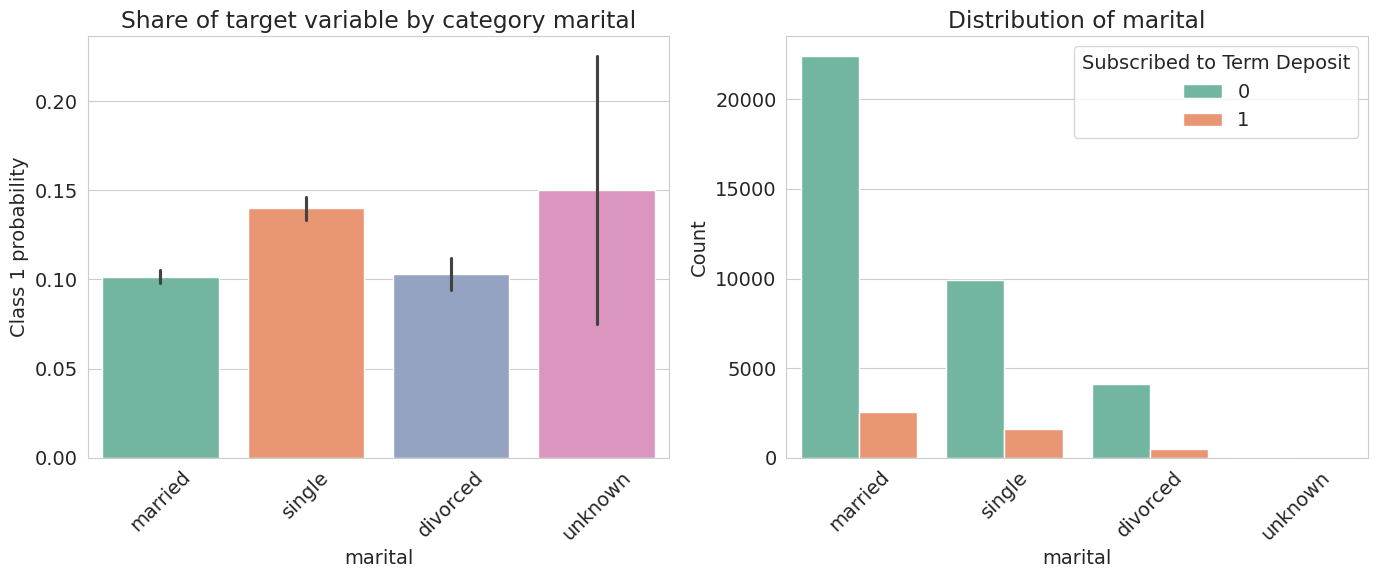

y,no,yes,no_pct,yes_pct
marital,,,,
unknown,68,12,85.000000,15.000000
single,9948,1620,85.995851,14.004149
divorced,4136,476,89.679098,10.320902
married,22396,2532,89.842747,10.157253


In [34]:
categor_plots(df, 'marital')
categor_table_report(df, 'marital', 'y')

**Спостереження:**

Клієнти, які ніколи не були одружені (single), мають найвищий відсоток успіху — 14.00%. Це може вказувати на те, що ця група є більш відкритою до нових фінансових пропозицій або має іншу фінансову поведінку, ніж одружені люди.

Клієнти, які одружені (married) та розлучені (divorced), мають схожий відсоток успіху, близько 10% (10.16% та 10.32% відповідно). Це свідчить про те, що сімейний статус, ймовірно, не є головним фактором у прийнятті рішення щодо депозиту.

 Категорія unknown має відсоток успіху 15.00%, що є найвищим показником серед усіх груп. Це може свідчити про те, що клієнти, які не розголошують свій сімейний статус, мають унікальні характеристики, які роблять їх більш схильними до підписання депозиту.

### Аналіз категоріальної ознаки 'education'

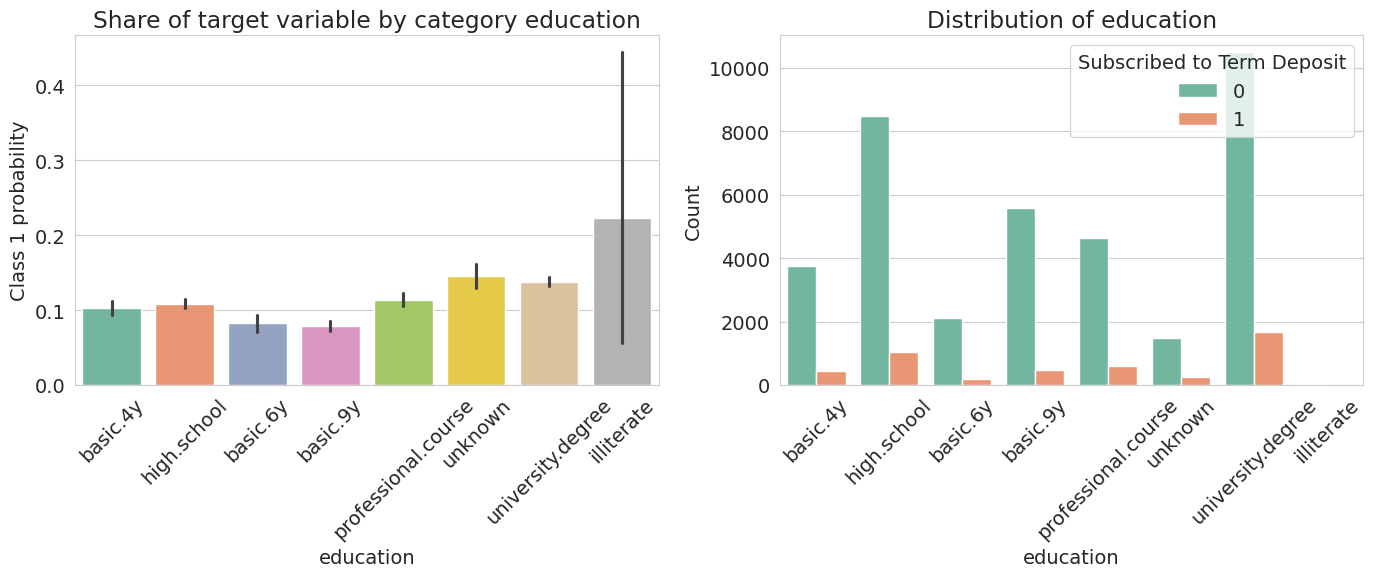

y,no,yes,no_pct,yes_pct
education,,,,
illiterate,14,4,77.777778,22.222222
unknown,1480,251,85.499711,14.500289
university.degree,10498,1670,86.275477,13.724523
professional.course,4648,595,88.651535,11.348465
high.school,8484,1031,89.164477,10.835523
basic.4y,3748,428,89.750958,10.249042
basic.6y,2104,188,91.797557,8.202443
basic.9y,5572,473,92.175352,7.824648


In [35]:
categor_plots(df, 'education')
categor_table_report(df, 'education', 'y')

**Спостереження:**

 Група illiterate (неписьменні) має найвищий відсоток успіху — 22.22%. Це може вказувати на те, що ці клієнти можуть бути більш довірливими або що для них менш доступні інші фінансові продукти, що робить депозит більш привабливим.

Клієнти з університетською освітою (university.degree) та ті, чия освіта невідома (unknown), також демонструють відносно високий відсоток успіху, близько 14-15%. Це вказує на те, що модель має враховувати як високий рівень освіти, так і її відсутність.

 Категорії professional.course, high.school та basic.4y мають схожий рівень успіху в діапазоні 10-11%, що є середнім показником.

 Клієнти з базовою освітою (basic.9y та basic.6y) мають найнижчий відсоток успіху — приблизно 7-8%. Це може бути пов'язано з їхнім фінансовим становищем або пріоритетами, що відрізняються від інших груп.


### Аналіз категоріальної ознаки 'default'

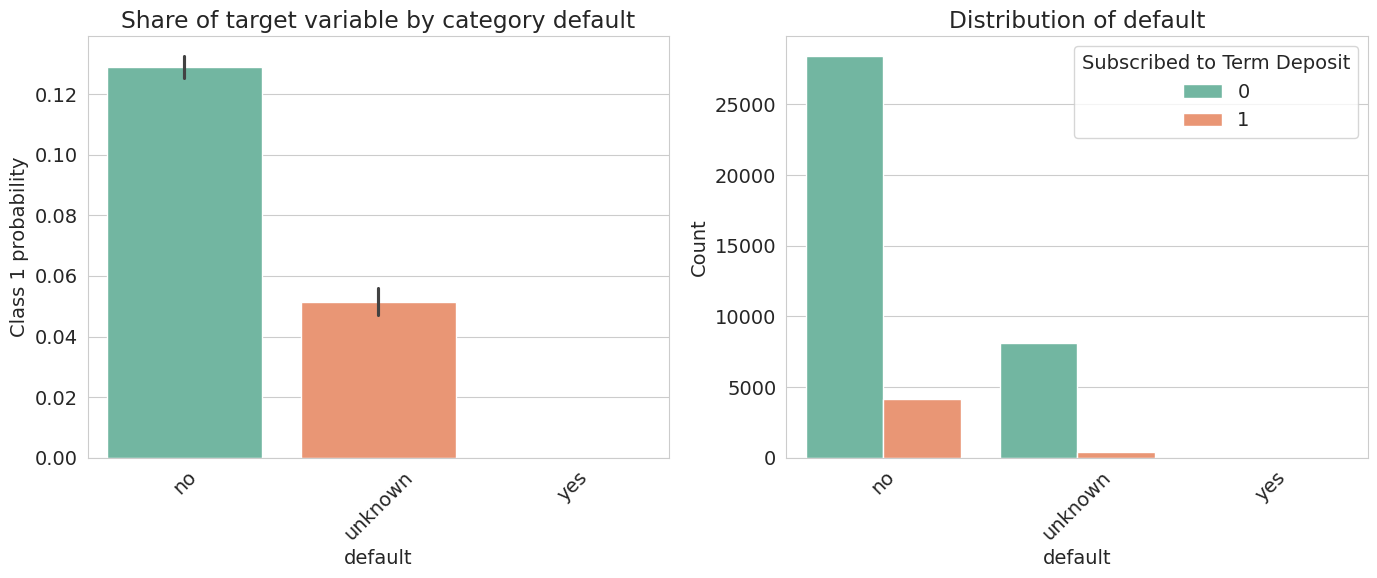

y,no,yes,no_pct,yes_pct
default,,,,
no,28391,4197,87.121026,12.878974
unknown,8154,443,94.847040,5.152960
yes,3,0,100.000000,0.000000


In [36]:
categor_plots(df, 'default')
categor_table_report(df, 'default', 'y')

**Спостереження:**

Переважна більшість клієнтів  не мають прострочених кредитів і серед них майже 13% оформлювали строковий депозит, що досить близько до розподілу цільової змінної.

Низький рівень (5%) позитивних результатів серед тих, хто має статус "unknown", може свідчити про те, що ця група клієнтів суттєво відрізняється від попередньої. Також нездатність банку підтвердити кредитну історію клієнта є негативним показником.

### Аналіз категоріальної ознаки 'housing'

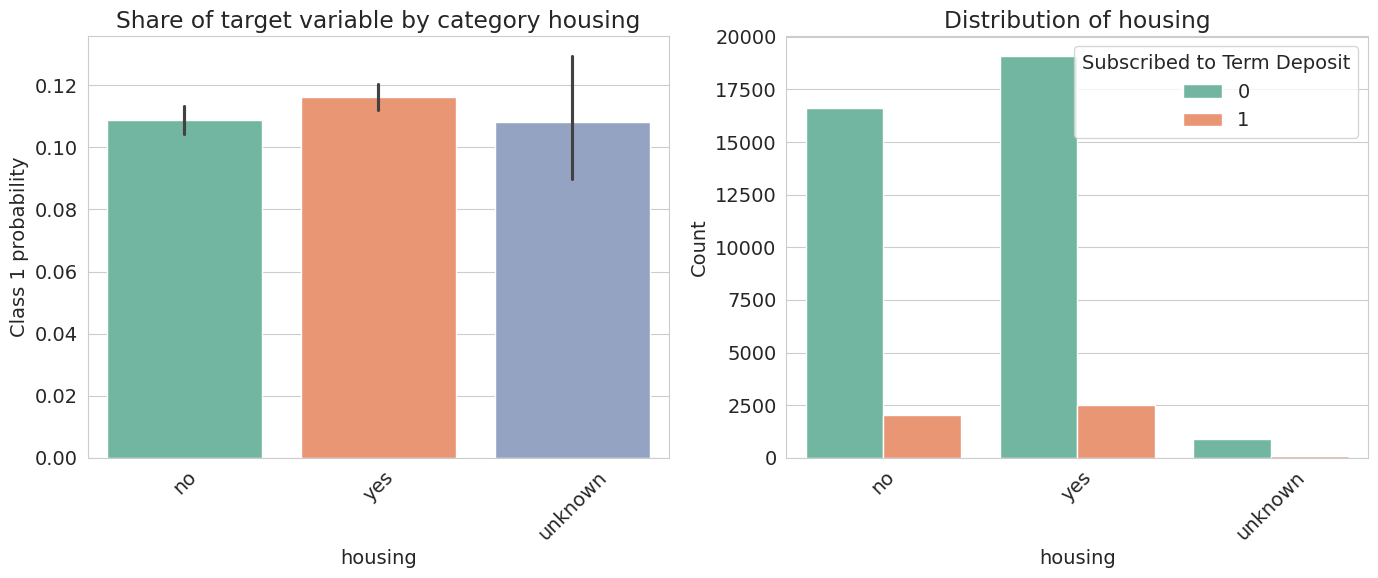

y,no,yes,no_pct,yes_pct
housing,,,,
yes,19069,2507,88.380608,11.619392
no,16596,2026,89.120395,10.879605
unknown,883,107,89.191919,10.808081


In [37]:
categor_plots(df, 'housing')
categor_table_report(df, 'housing', 'y')

**Спостереження:**

Розподіл усіх категорій близький до розподілу цільової змінної, швидше за все ця змінна буде малоінформативною для прогнозування.

### Аналіз категоріальної ознаки 'loan'

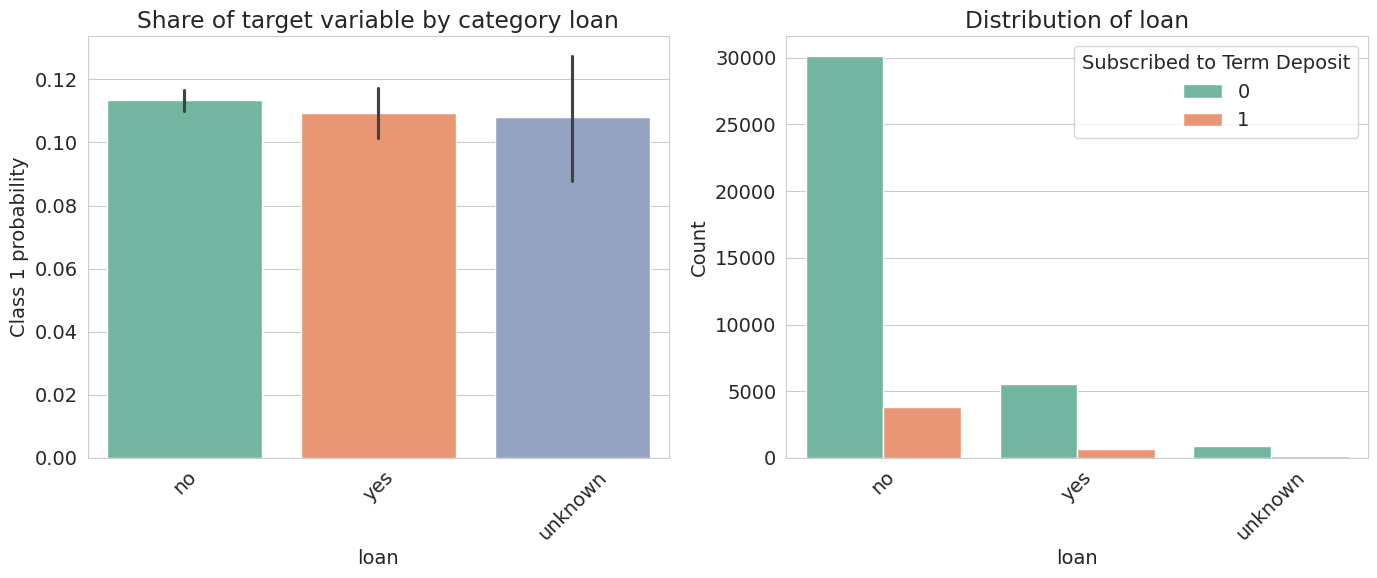

y,no,yes,no_pct,yes_pct
loan,,,,
no,30100,3850,88.659794,11.340206
yes,5565,683,89.068502,10.931498
unknown,883,107,89.191919,10.808081


In [38]:
categor_plots(df, 'loan')
categor_table_report(df, 'loan', 'y')

**Спостереження:**

Розподіл усіх категорій близький до розподілу цільової змінної, швидше за все ця змінна буде малоінформативною для прогнозування.

### Аналіз категоріальної ознаки 'contact'

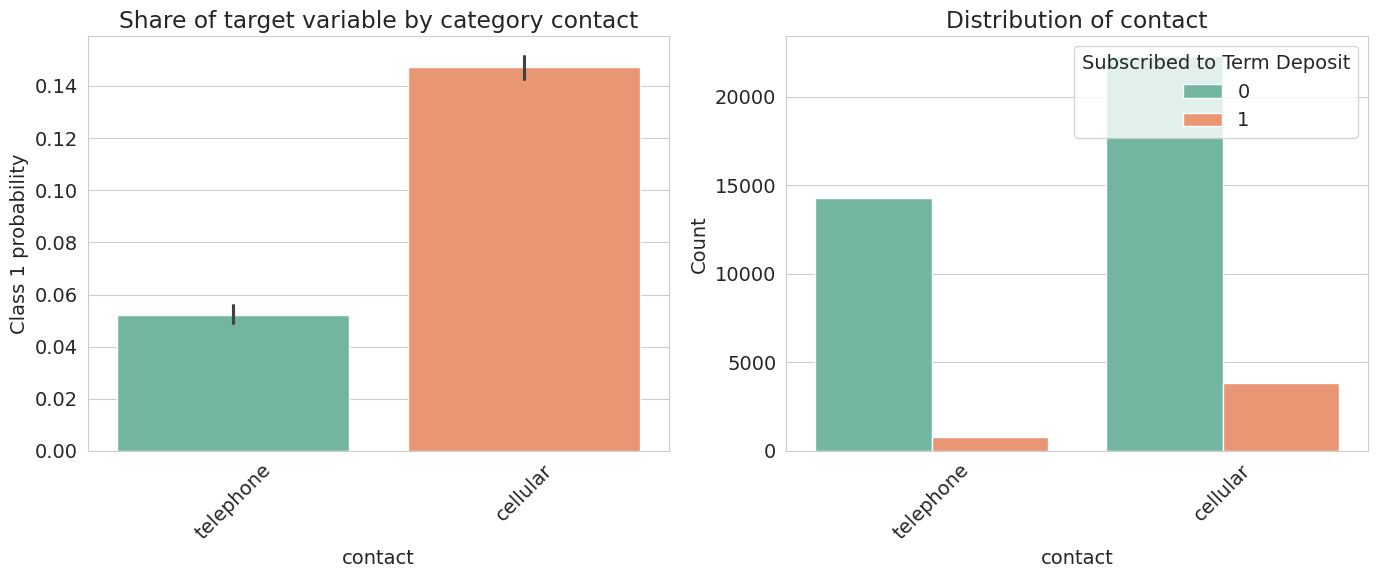

y,no,yes,no_pct,yes_pct
contact,,,,
cellular,22291,3853,85.262393,14.737607
telephone,14257,787,94.768679,5.231321


In [39]:
categor_plots(df, 'contact')
categor_table_report(df, 'contact', 'y')

**Спостереження:**

Для ознаки contact відсоток успешних угод значно відрізняється від типу контакту. Спостерігаємо значну перевагу для контактів, які здійснені через мобільний зв'язок  14.74%, порівняно з контактами по стаціонарному телефону - лише 5.23%.

### Аналіз категоріальної ознаки 'month'

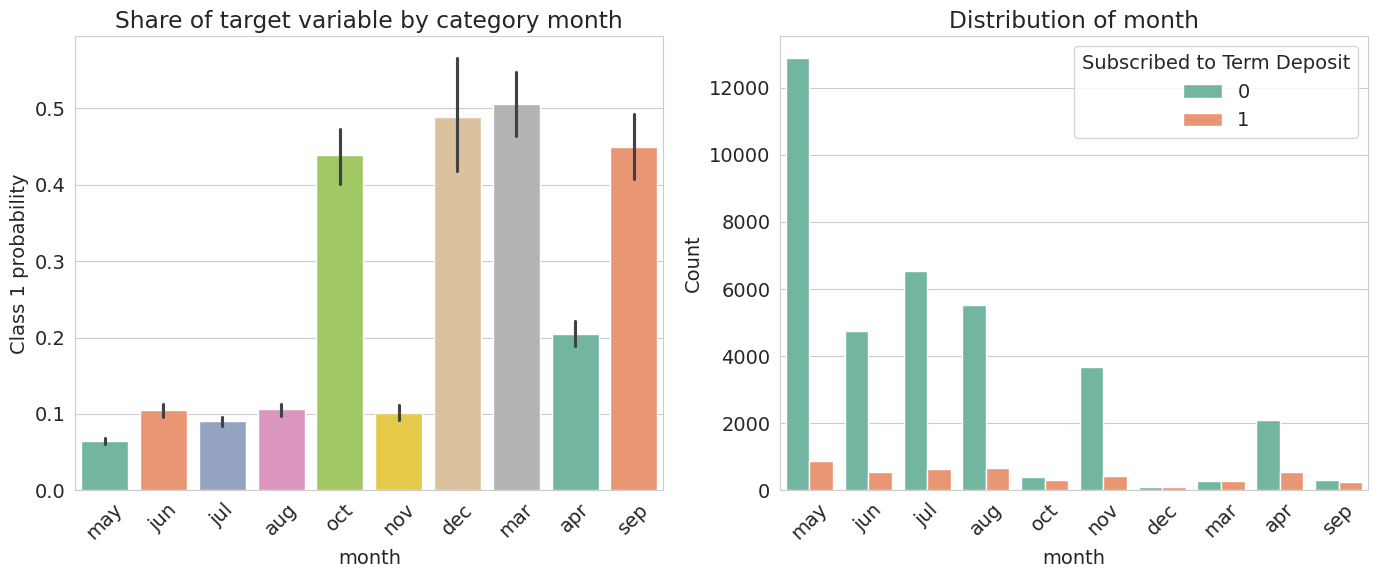

y,no,yes,no_pct,yes_pct
month,,,,
mar,270,276,49.450549,50.549451
dec,93,89,51.098901,48.901099
sep,314,256,55.087719,44.912281
oct,403,315,56.128134,43.871866
apr,2093,539,79.521277,20.478723
aug,5523,655,89.397863,10.602137
jun,4759,559,89.488530,10.511470
nov,3685,416,89.856133,10.143867
jul,6525,649,90.953443,9.046557


In [40]:
categor_plots(df, 'month')
categor_table_report(df, 'month', 'y')

**Спостереження:**

Найуспішніші місяці

Березень (mar): 50.55%. Кожен другий клієнт, з яким контактували у березні, підписав депозит.

Грудень (dec): 48.90%.

Жовтень (oct) та Вересень (sep):  43.87% та 44.91% відповідно.

Найменш успішні місяці

Травень (may): 6.43%.

Липень (jul), Червень (jun), Серпень (aug): Літні місяці також демонструють низькі показники успішності, в діапазоні 9-11%.

Листопад (nov): 10.14%.

Змінна month є надзвичайно важливою для моделі. Вона  дозволяє визначити найбільш і найменш сприятливі періоди для контакту з клієнтами.

### Аналіз категоріальної ознаки 'day_of_week'

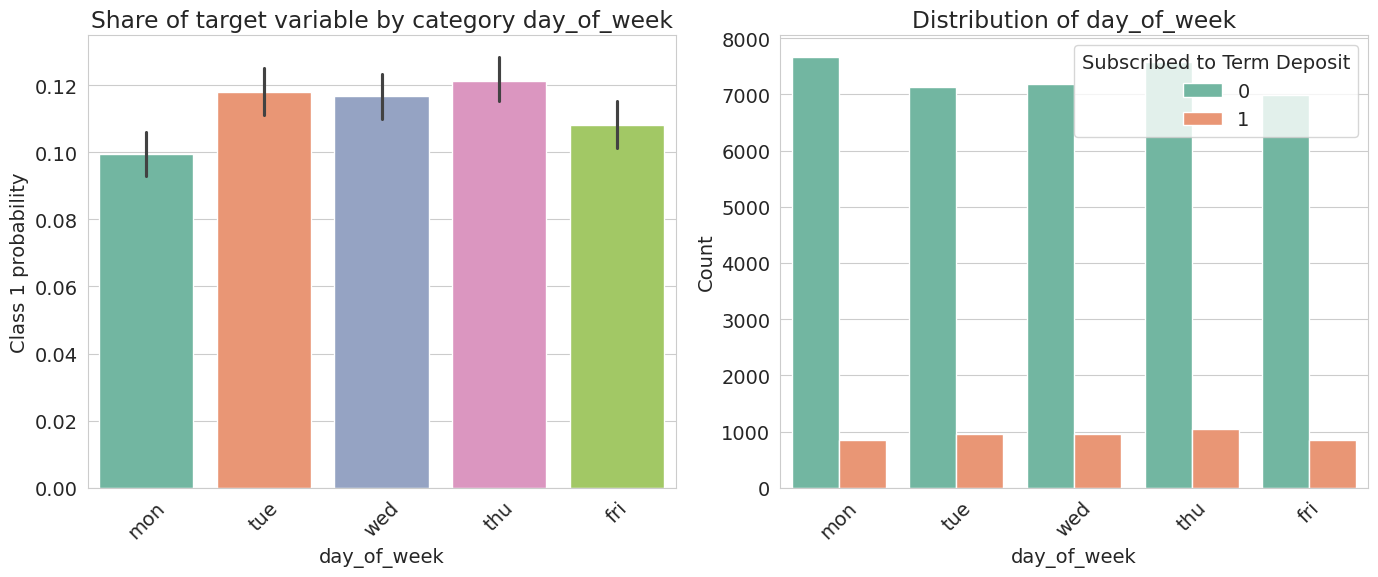

y,no,yes,no_pct,yes_pct
day_of_week,,,,
thu,7578,1045,87.881248,12.118752
tue,7137,953,88.220025,11.779975
wed,7185,949,88.332924,11.667076
fri,6981,846,89.191261,10.808739
mon,7667,847,90.051680,9.948320


In [41]:
categor_plots(df, 'day_of_week')
categor_table_report(df, 'day_of_week', 'y')

**Спостереження:**

На відміну від місяців дні тижня не відіграють такої важливої ролі. Трохи нижче значення для понеділка 9.9% і вище для четверга 12.11%. В цілому розподіл близький до рівномірного, а також близький до розподілу цільової змінної.

### Аналіз категоріальної ознаки 'poutcome'

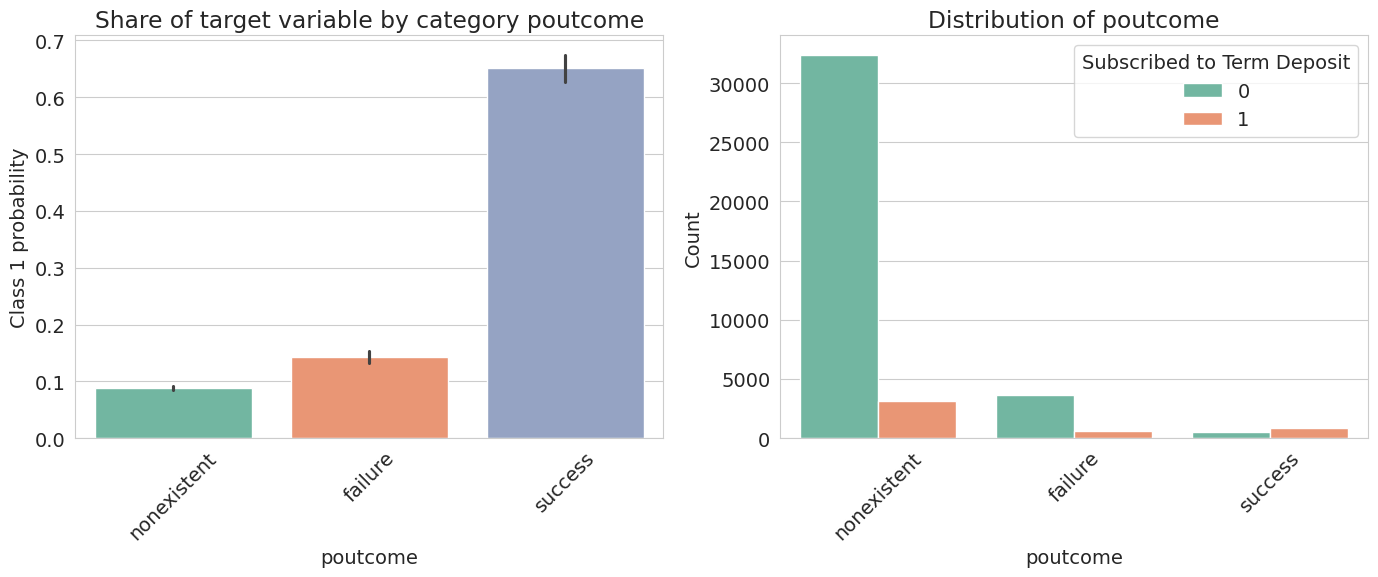

y,no,yes,no_pct,yes_pct
poutcome,,,,
success,479,894,34.887109,65.112891
failure,3647,605,85.771402,14.228598
nonexistent,32422,3141,91.167787,8.832213


In [42]:
categor_plots(df, 'poutcome')
categor_table_report(df, 'poutcome', 'y')

**Спостереження:**

nonexistent: відсоток успіху в цій групі дуже низький — лише 8.83%. Це має сенс, оскільки ця категорія, ймовірно, включає багато нових клієнтів або тих, хто не реагував на попередні кампанії.

failure: клієнти, які вже відмовилися в попередніх кампаніях, мають відносно низький відсоток успіху — 14.23%. Хоча це значно вище, ніж у групі nonexistent, це все одно вказує на те, що клієнти з попереднім негативним досвідом не є найкращими кандидатами.

success: клієнти, які вже успішно підписалися на послугу в попередній кампанії, демонструють надзвичайно високий відсоток успіху — 65.11%. Це найпотужніший показник у ваших даних.

Змінна poutcome є найважливою для прогнозування.

**Висновок:**

З поміж категоріальних ознак попередньо найважливішими є:
- poutcome
- month
- job
- contact


# Тренування моделей

## Preprocessing

In [43]:
def remove_outliers_iqr(df, column, n = 1.5, remove = False):
    """
    Виявляє та видаляє (remove = Ture) викиди зі вказаного стовпця DataFrame
    за допомогою методу міжквартильного розмаху (IQR).

    Параметри:
    - df (pd.DataFrame): Вхідний DataFrame.
    - column (str): Назва стовпця, в якому шукати викиди.
    - n: коефіцієнт міжквартильного розмаху.
    - remove: видаляти чи ні спостереження з викидами.

    Повертає:
    - pd.DataFrame: DataFrame без викидів, якщо викиди видаляються.

    """
    print(df[column].min(), '<=', column, '<=', df[column].max())

    # Обчислення Q1, Q3 та IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Визначення меж для викидів
    lower_bound = Q1 - n * IQR
    upper_bound = Q3 + n * IQR

    print("Визначення меж для викидів")
    print(f'Q1 - {n} * IQR =', lower_bound)
    print(f'Q3 + {n} * IQR =', upper_bound, '\n')

    # Виявлення викидів
    outliers_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    outliers_df = df[outliers_mask]

    if remove:
      df_no_outliers = df[~outliers_mask]
      print(f"Зі стовпця '{column}' видалено {len(outliers_df)} викидів.")
      return df_no_outliers, outliers_df

In [44]:
# Видалення дублікатів та перевірка
df.drop_duplicates(keep='first',inplace=True)
df.duplicated().sum()

np.int64(0)

**pdays**

Можливі способи обробки змінної, які б зберегли її інформаційну цінність:

створення бінарної змінної "had_previous_contact", де 1 означає, що клієнт контактувався раніше (pdays < 999), а 0 — ні. Це дозволить моделі чітко розрізняти ці дві групи,

перетворення змінної pdays на категоріальну змінну, де значення 999 замінюється на 'no_contact', всі значення менше 10, їх небагато, на 'rare_contact',

заміна 999 на -1 спростить дані, буде більш логічним і надійним рішенням для більшості моделей.

З огляду на набір даних, найефективнішим буде використання бінарної змінної "had_previous_contact" або заміна 999 на -1, ці підхіди забезпечать найкращий баланс між збереженням інформації та уникненням великої кількості додаткових колонок і збільшення розмірності.

In [45]:
df.loc[df['pdays'] == 999, 'pdays'] = -1

In [46]:
df.pdays.unique()

array([-1,  6,  4,  3,  5,  1,  0, 10,  7,  8,  9, 11,  2, 12, 13, 14, 15,
       16, 21, 17, 18, 22, 25, 26, 19, 27, 20])

In [47]:
# Визначення колонок, які можуть містити викиди
columns_to_check = ['age', 'duration', 'campaign']
for col in columns_to_check:
  print(f'Для змінної  {col}')
  remove_outliers_iqr(df, col, n = 2, remove = False)

Для змінної  age
17 <= age <= 98
Визначення меж для викидів
Q1 - 2 * IQR = 2.0
Q3 + 2 * IQR = 77.0 

Для змінної  duration
0 <= duration <= 4918
Визначення меж для викидів
Q1 - 2 * IQR = -332.0
Q3 + 2 * IQR = 753.0 

Для змінної  campaign
1 <= campaign <= 56
Визначення меж для викидів
Q1 - 2 * IQR = -3.0
Q3 + 2 * IQR = 7.0 



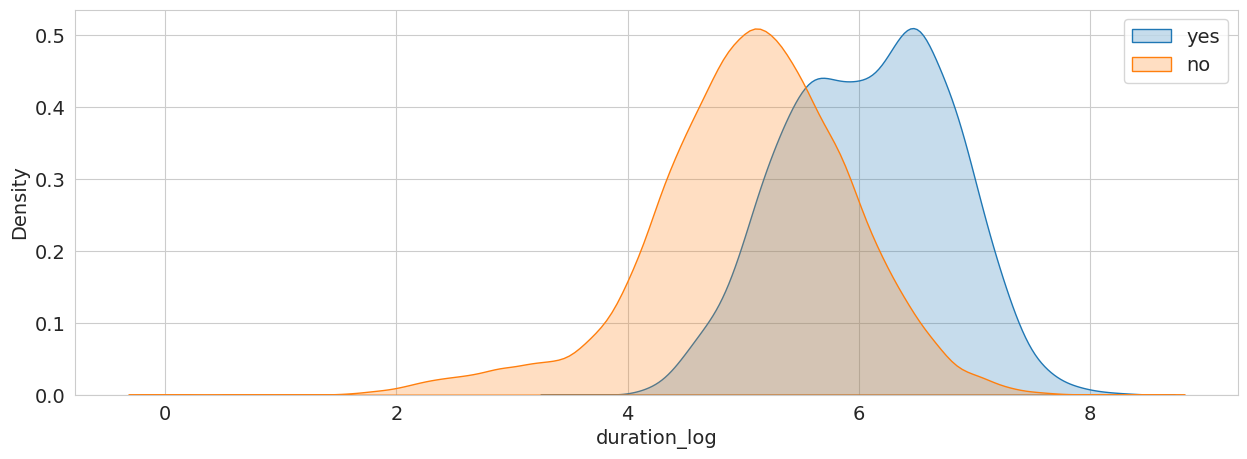

In [48]:
df['duration_log'] = np.log1p(df['duration'])
sns.kdeplot(data=df[df['y'] == 'yes'], x='duration_log', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='duration_log', label='no', fill=True)
plt.legend()
plt.show()

Після логарифмування (duration_log):

- Розподіли стали більш симетричними — тепер видно “дзвоники” для обох груп.

- Чіткіше розділення класів — клієнти з відповіддю “no” мають максимум на менших значеннях логарифма (коротші дзвінки), а клієнти з “yes” — зсуваються правіше (довші дзвінки).

- Модельні вигоди: логарифмування полегшує роботу алгоритмів, особливо тих, які чутливі до масштабу та форми розподілу (лінійна регресія, логістична регресія, дерева). У такій формі змінна стає «більш лінійною» у зв’язку з цільовою.

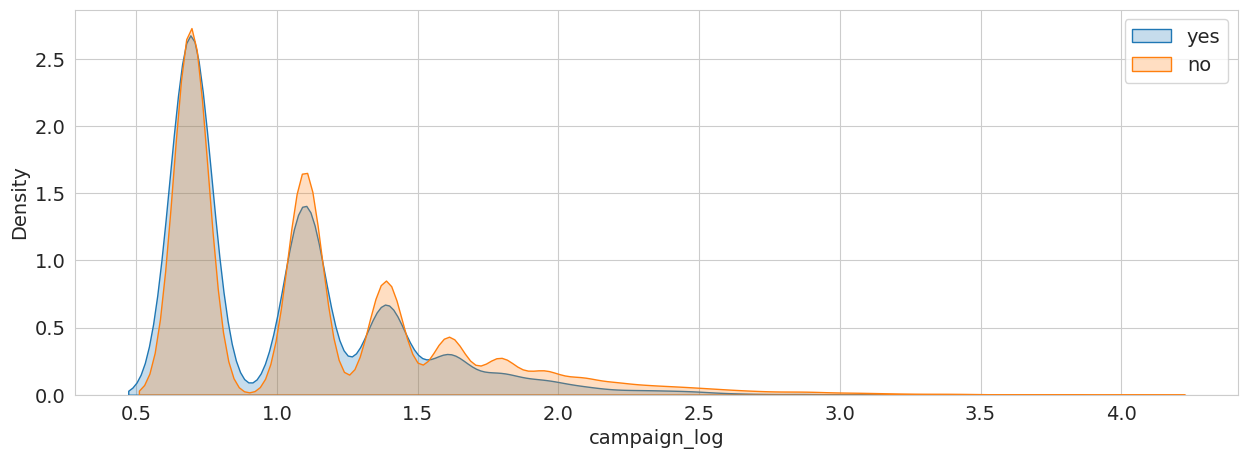

In [49]:
df['campaign_log'] = np.log1p(df['campaign'])
sns.kdeplot(data=df[df['y'] == 'yes'], x='campaign_log', label='yes', fill=True)
sns.kdeplot(data=df[df['y'] == 'no'], x='campaign_log', label='no', fill=True)
plt.legend()
plt.show()

Чи є сенс логарифмувати?

- Так, сенс може бути, бо змінна має дуже сильний скіс вправо.

- Логарифмування “стисне” великі значення і зробить розподіл більш симетричним. Це допоможе моделям, які погано працюють з сильно скошеними ознаками (лінійні моделі, логістична регресія).

- Проте більшість даних сконцентрована у малих значеннях (1–5). Після логарифмування різниця між 1 і 2 (що є суттєвою!) зменшиться, а різниця між 20 і 50 “стиснеться” ще більше. Це може навіть трохи знизити інформативність у простих моделей.

- Можна створити категоріальні групи:
  - low_contacts (1–3 дзвінки),

  - medium_contacts (4–7 дзвінків),

  - high_contacts (7 і більше дзвінків).
  
  Це може дати інтуїтивніше трактування і допомогти моделі.

In [50]:
# Заміна значень unknown модою
cat_col_unknown = ['job', 'marital', 'housing', 'loan']
for col in cat_col_unknown:
  df.loc[df[col] == 'unknown', col] = df[col].mode()

Для колонок education та default	значення 'unknown' відіграють важливу роль, тому лишаю їх окремими категоріями, без заміни.

In [51]:
df_log_reg = df[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign_log', 'pdays','duration_log',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_num']].copy()

In [52]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_log_reg, stratify = df_log_reg['y_num'], test_size=0.2, random_state=42)
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)

train_df.shape : (32940, 21)
val_df.shape : (8236, 21)


In [53]:
input_cols = list(train_df.columns)[:-1]
target_col = 'y_num'
print(input_cols)

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign_log', 'pdays', 'duration_log', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [54]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [55]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [56]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [57]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

train_inputs[numeric_cols].describe().round(2)

,age,campaign_log,pdays,duration_log,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00,32940.00
mean,0.28,0.13,0.01,0.62,0.02,0.73,0.54,0.43,0.68,0.77
std,0.13,0.15,0.05,0.11,0.07,0.33,0.23,0.19,0.39,0.27
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.19,0.00,0.00,0.56,0.00,0.33,0.34,0.34,0.16,0.51
50%,0.26,0.12,0.00,0.62,0.00,0.94,0.60,0.38,0.96,0.86
75%,0.37,0.21,0.00,0.69,0.00,1.00,0.70,0.60,0.98,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [58]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop =  'first', sparse_output=False, handle_unknown='infrequent_if_exist')
encoder.fit(train_inputs[categorical_cols])

encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [59]:
display(train_inputs.head()), display(val_inputs.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
36454,0.086420,technician,single,professional.course,no,no,no,cellular,jun,tue,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1233,0.185185,blue-collar,married,professional.course,no,no,no,telephone,may,thu,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
24111,0.197531,self-employed,single,university.degree,no,no,no,telephone,nov,thu,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
15516,0.259259,entrepreneur,married,basic.9y,no,no,yes,telephone,jul,fri,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
17916,0.271605,services,married,high.school,no,yes,yes,cellular,jul,tue,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
8490,0.222222,services,married,high.school,unknown,no,no,telephone,jun,wed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
40844,0.160494,student,single,professional.course,no,yes,no,cellular,sep,tue,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
35681,0.246914,self-employed,single,basic.4y,no,yes,no,cellular,may,mon,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
35994,0.172840,blue-collar,single,professional.course,no,no,no,cellular,may,tue,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
21961,0.172840,technician,married,university.degree,no,NaN,NaN,cellular,aug,wed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


(None, None)

### Вибір та обгрунтування метрик

**Метрики**, стійкі до незбалансованих класів:

***F1-score*** є середнім гармонійним між Precision та Recall і особливо корисна, коли потрібно збалансувати ці дві метрики. F1-score набуває високого значення лише тоді, коли і Precision, і Recall є високими. Це змушує модель не тільки точно визначати позитивні випадки, але й знаходити їх більшість.

***ROC AUC*** не чутлива до співвідношення класів, вимірює здатність моделі розрізняти класи за різних порогів класифікації.

In [60]:
model_report= pd.DataFrame({'model': [], 'f1_train':[], 'f1_val':[], 'train_auroc': [], 'val_auroc': [], 'auroc_dif': [], 'best_param' : [], 'info':[]})
random_state_fix = 42

In [61]:
def AUROC_report_for_model(model, X_train, X_val, train_targets, val_targets):
  train_proba = model.predict_proba(X_train)[:, 1]
  val_proba = model.predict_proba(X_val)[:, 1]

  train_predict  = model.predict(X_train)
  val_predict = model.predict(X_val)

  train_auroc = round(roc_auc_score(train_targets, train_proba), 5)
  val_auroc = round(roc_auc_score(val_targets, val_proba), 5)

  # Обчислюємо матриці і метрики
  cm_train = confusion_matrix(train_targets, train_predict, normalize='true')
  cm_test = confusion_matrix(val_targets, val_predict, normalize='true')

  # Малюємо поруч
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
  axes[0].set_title(f'Train Confusion Matrix')

  ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
  axes[1].set_title(f'Validation Confusion Matrix')

  plt.tight_layout()
  plt.show()

  return train_auroc, val_auroc

In [62]:
from sklearn.metrics import f1_score

def get_f1_score(model, inputs, targets, name='', threshold = 0.5):
  y_pred_proba = model.predict_proba(inputs)[:, 1]
  y_pred_05 = (y_pred_proba >= threshold).astype(int)

  f1_score_ = f1_score(targets, y_pred_05)
  print(f"F1 score {name}: {f1_score_:.3f}")

  return f1_score_

In [63]:
def auroc_train_and_val(model, X_train, X_val, train_targets, val_targets):

  train_probs = model.predict_proba(X_train)
  val_probs = model.predict_proba(X_val)

  # рахуємо ROC-криві
  fpr_train, tpr_train, _ = roc_curve(train_targets, train_probs[:, 1])
  fpr_val, tpr_val, _ = roc_curve(val_targets, val_probs[:, 1])

  # обчислюємо AUC
  auc_train = roc_auc_score(train_targets, train_probs[:, 1])
  auc_val = roc_auc_score(val_targets, val_probs[:, 1])

  # будуємо графік
  plt.figure(figsize=(8, 6))
  plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.4f})")
  plt.plot(fpr_val, tpr_val, label=f"Validation ROC (AUC = {auc_val:.4f})")
  plt.plot([0, 1], [0, 1], linestyle='--', color='green')

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend()
  plt.show()

In [64]:
def total_report(model, X_train, X_val, train_targets, val_targets, model_name, best_param = None):

  global model_report

  f1_train = get_f1_score(model, X_train, train_targets, 'Training')
  f1_val = get_f1_score(model,  X_val, val_targets, 'Validation')

  train_auroc, val_auroc = AUROC_report_for_model(model, X_train, X_val, train_targets, val_targets)

  auroc_train_and_val(model, X_train, X_val, train_targets, val_targets)

  # нові результати
  new_row = {
      'model': model_name,
      'f1_train':f1_train,
      'f1_val':f1_val,
      'train_auroc': train_auroc,
      'val_auroc': val_auroc,
      'auroc_dif': train_auroc - val_auroc,
      'best_param': best_param,
      'with_duration': 1
  }

  # додаємо
  model_report = pd.concat([model_report, pd.DataFrame([new_row])], ignore_index=True)

## Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', random_state = random_state_fix)

F1 score Training: 0.517
F1 score Validation: 0.507


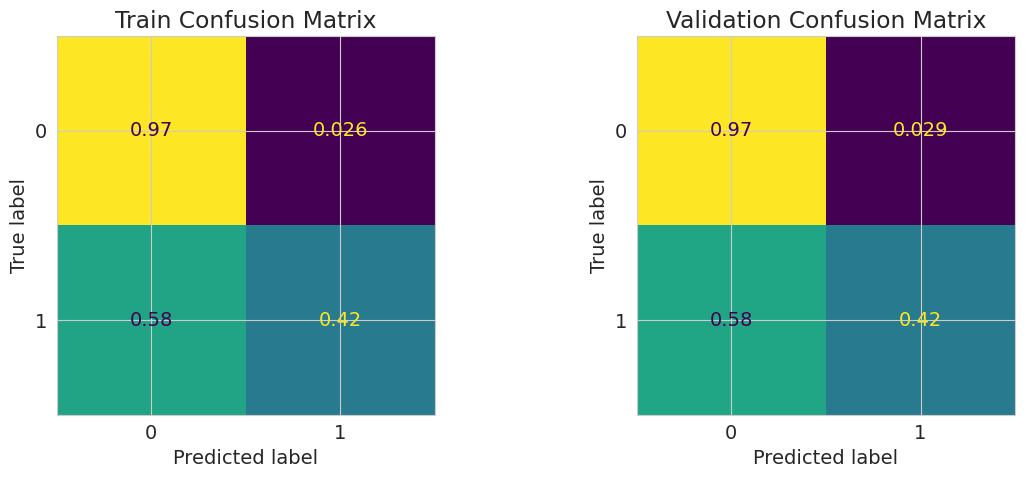

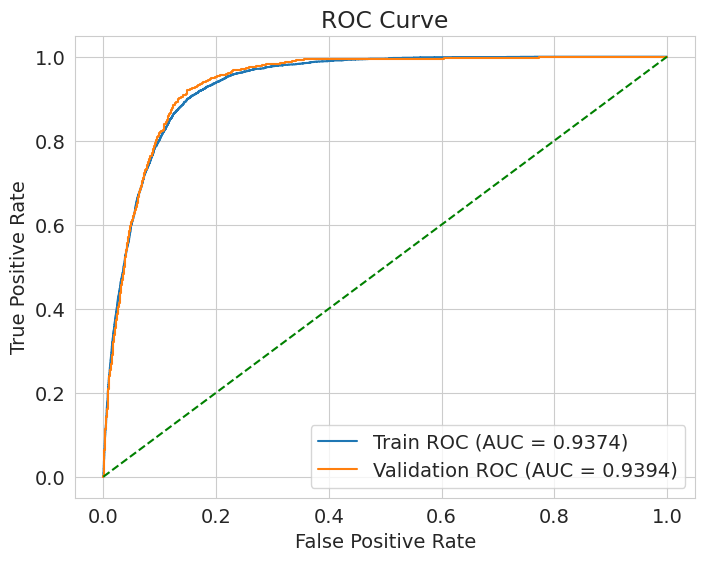

In [66]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

model.fit(X_train, train_targets)

total_report(model, X_train, X_val, train_targets, val_targets, model_name = 'LogisticRegression_example', best_param = {'solver':'liblinear', 'random_state':42})

**Висновки**:

Базова логістична регресія. F1 ≈ 0.51, AUROC ≈ 0.94. Модель стабільна (train ≈ val). Може бути використана як стартова модель, але можна покращити через розширення ознак або додаванням поліноміальних ознак.


In [67]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, classification_report, root_mean_squared_error, r2_score

F1 score Training: 0.521
F1 score Validation: 0.514


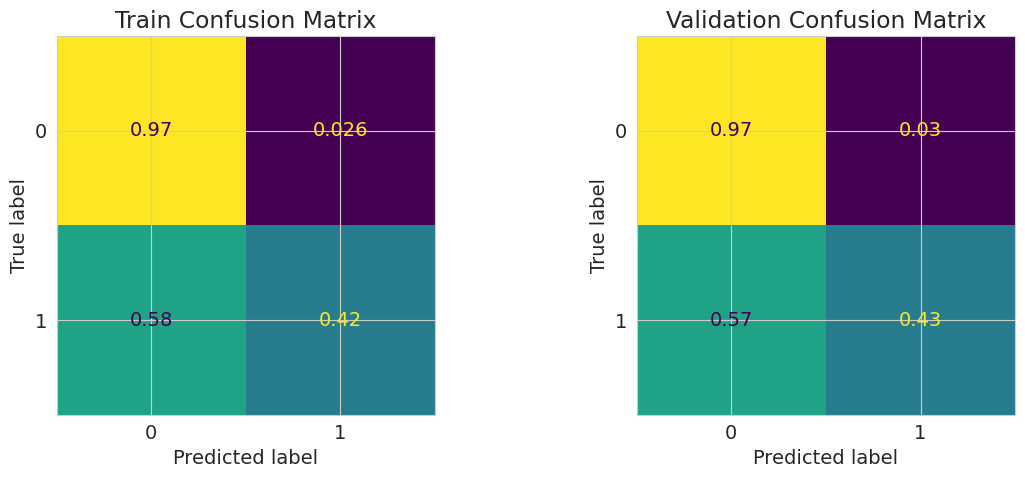

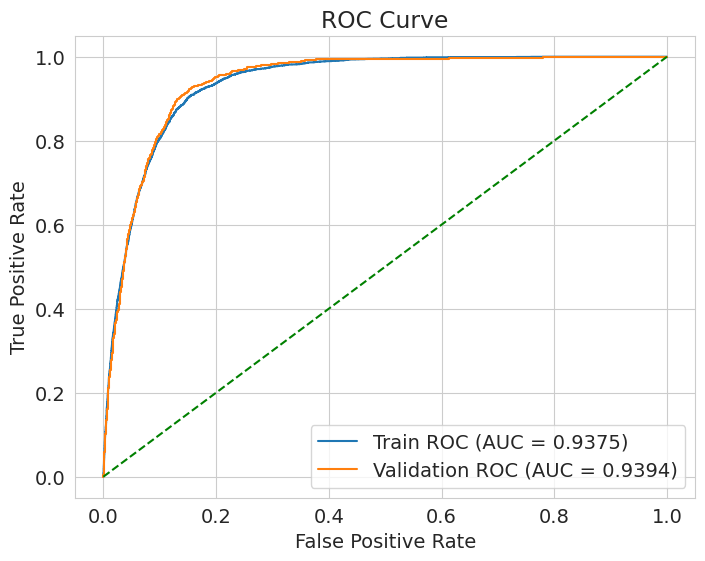

In [68]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state = 42))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

total_report(model_pipeline, train_inputs, val_inputs, train_targets, val_targets, model_name = 'LogisticRegression_pipeline', best_param = {'solver':'liblinear', 'random_state':42})

**Висновки**:

Pipeline з препроцесінгом дає невелике покращення F1 (0.52). AUROC стабільний. Варто використовувати як базову.

F1 score Training: 0.553
F1 score Validation: 0.561


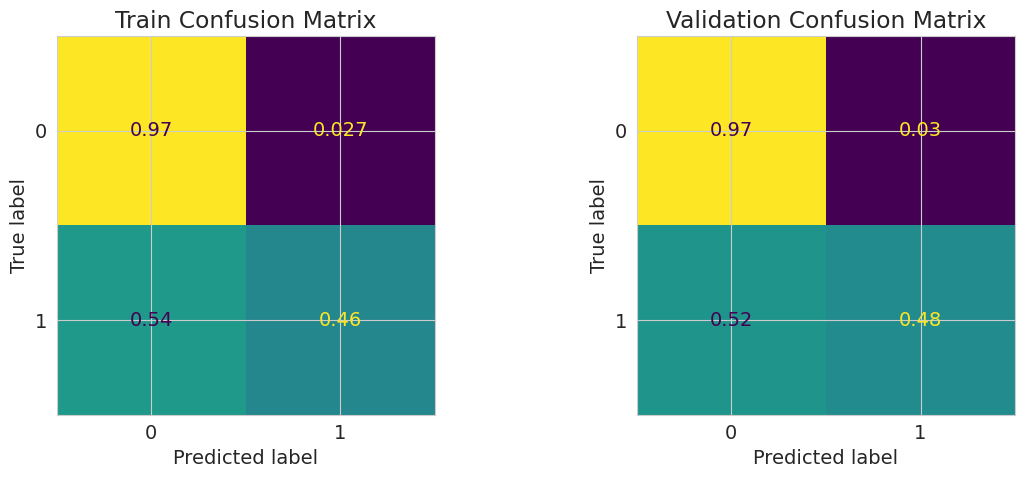

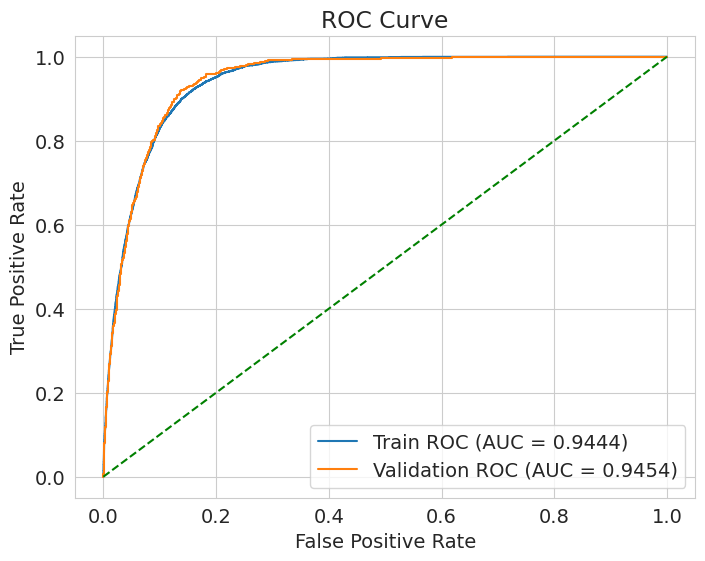

In [69]:
import operator
from sklearn.preprocessing import PolynomialFeatures

# Створюємо трансформери для числових і категоріальних колонок колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial_features', PolynomialFeatures(degree=5))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_pol2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state = 42))
])

# Тренуємо пайплайн
model_pipeline_pol2.fit(train_inputs, train_targets)

total_report(model_pipeline_pol2, train_inputs, val_inputs, train_targets, val_targets, model_name = 'LogisticRegression_pipeline_degree_5', best_param = {'solver':'liblinear', 'random_state':42, 'polinom_degree':5})

**Висновки:**

Поліноміальні ознаки (степінь 5) дають найвищий F1 серед логістичних моделей (0.56). AUROC дуже високий. Гарна модель, але варто перевірити перенавчання на нових даних.

## kNN

In [70]:
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

F1 score Training: 1.000
F1 score Validation: 0.393


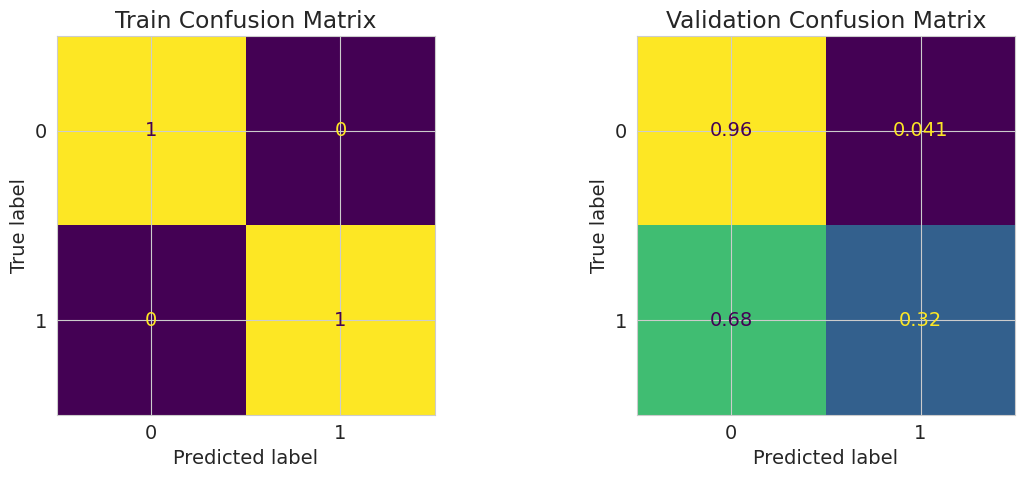

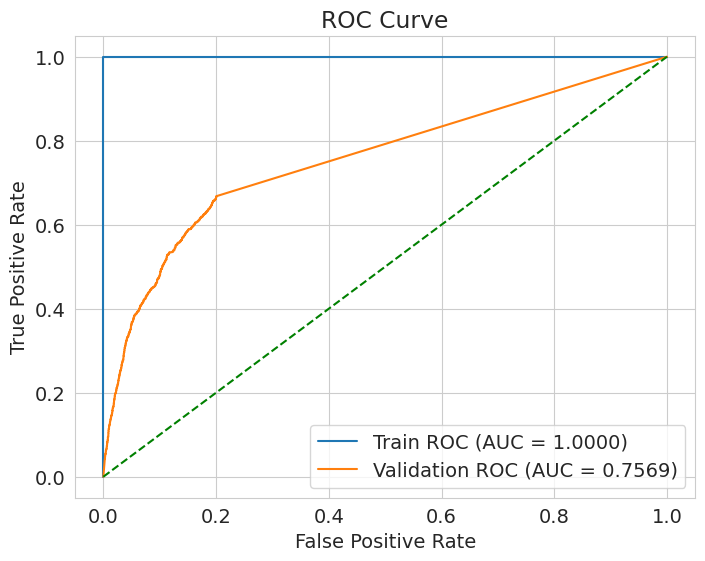

In [71]:
knn = KNeighborsClassifier(n_neighbors = 4, weights = 'distance')
knn.fit(X_train, train_targets)

total_report(knn, X_train, X_val, train_targets, val_targets, model_name = 'KNeighborsClassifier', best_param = {'n_neighbors':4, 'weights':'distance'})

**Висновки:**

Дуже висока F1 на train (1.0), але сильне падіння на val (0.39). Перенавчання. Використовувати не можна без регуляризації або зміни кількості сусідів.

In [72]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)
print('Найкраще значення параметра', knn_gs.best_params_)

Найкраще значення параметра {'n_neighbors': np.int64(23)}


F1 score Training: 0.299
F1 score Validation: 0.267


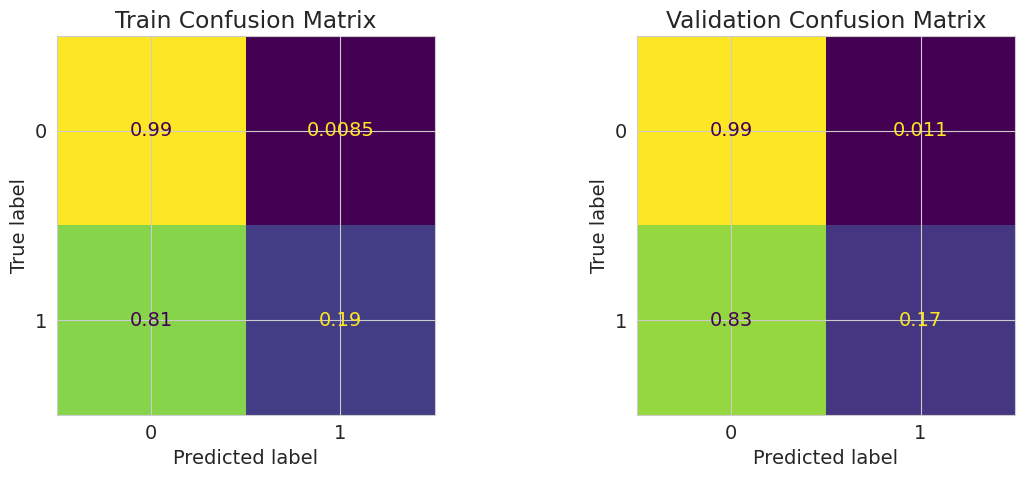

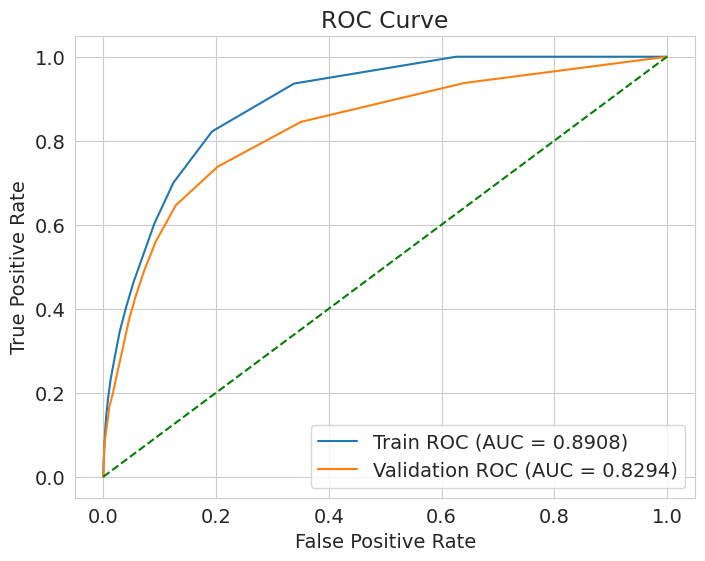

In [73]:
knn_best = knn_gs.best_estimator_

total_report(knn_best, X_train, X_val, train_targets, val_targets, model_name = 'KNeighborsClassifier_knn_best', best_param = knn_gs.best_params_)

**Висновки:**

Більш “помірна” конфігурація. F1 низький (0.27). Недостатньо ефективна. Можна спробувати оптимізацію weights, metric та масштабування ознак.

## Decision Tree

F1 score Training: 0.786
F1 score Validation: 0.564


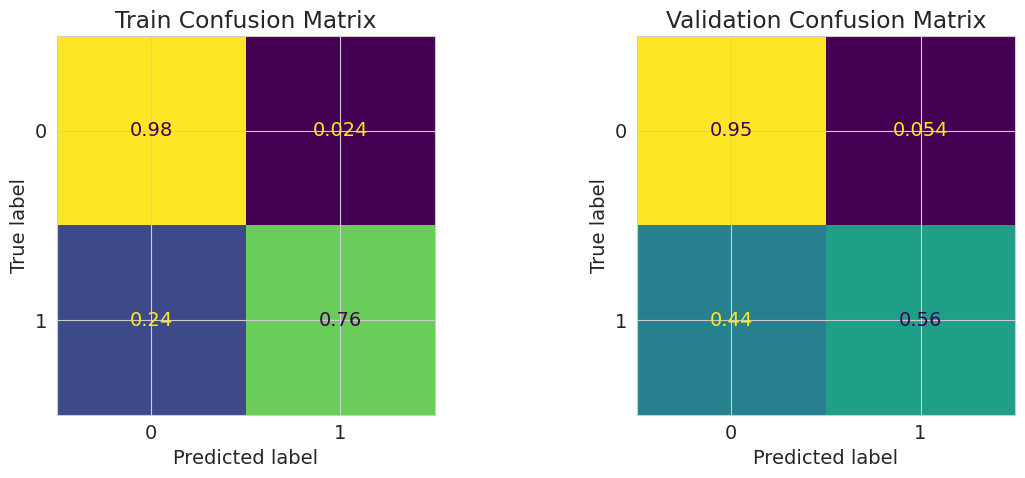

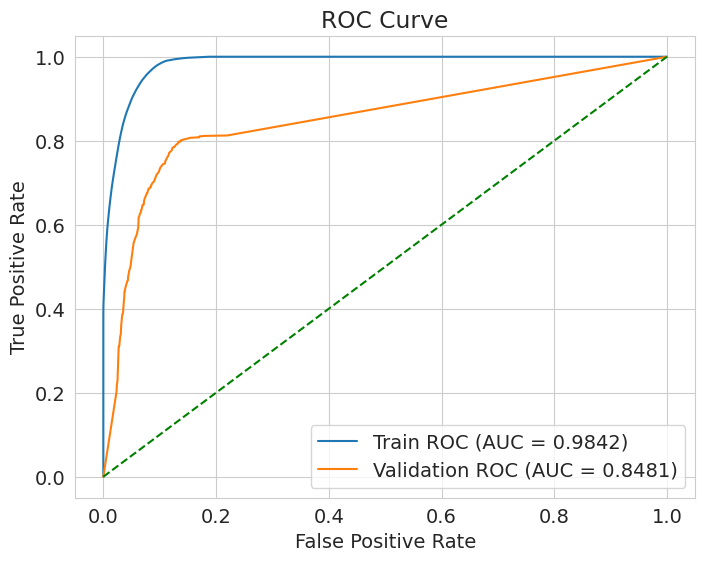

In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve

y_train = train_targets
y_val = val_targets

model = DecisionTreeClassifier(criterion = "entropy", max_depth = 13, random_state=42)
model.fit(X_train, y_train)

total_report(model, X_train, X_val, train_targets, val_targets, model_name = 'DecisionTreeClassifier', best_param = {'criterion':"entropy", 'max_depth': 13, 'random_state':42})

**Висновки:**

F1 train 0.79 vs val 0.56, AUROC train 0.98 vs val 0.85. Перенавчання, але модель дає непогану AUROC. Варто обмежити max_depth або min_samples_leaf, або використовувати ансамблі дерев.

In [75]:
importance_df = model.feature_importances_.round(2)

In [76]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

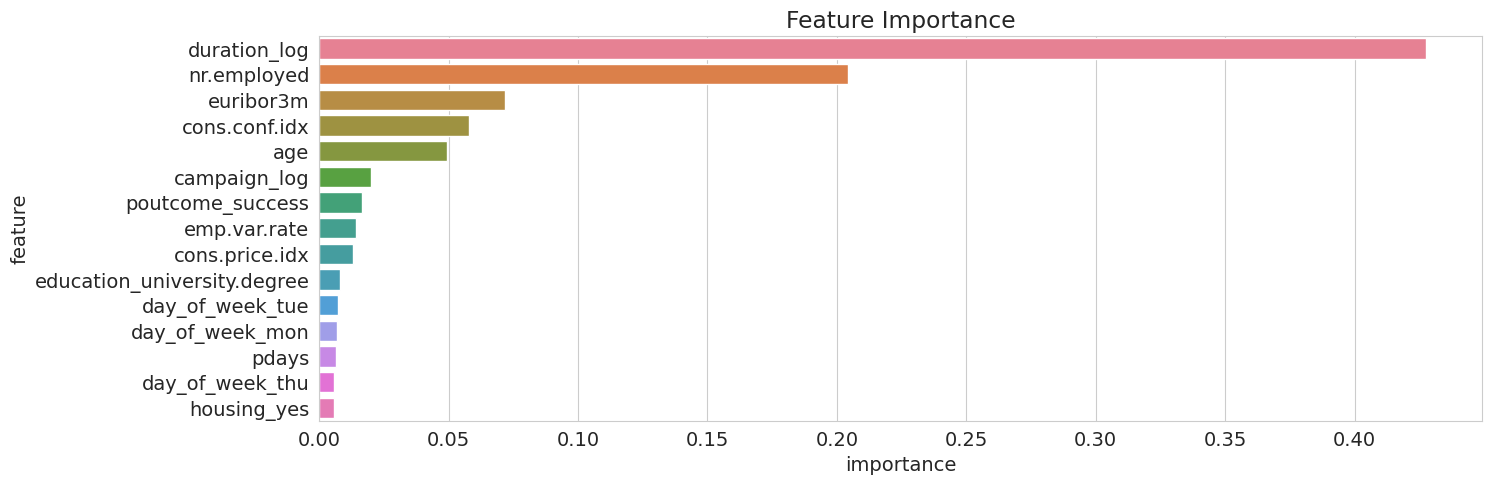

In [77]:
import seaborn as sns
sns.barplot(
    data=importance_df.head(15),
    x='importance',
    y='feature',
    hue='feature',  # щоб різні кольори були для кожної ознаки
    palette=sns.color_palette("husl", 15),
)
plt.title('Feature Importance')
plt.show()


In [78]:
from sklearn.model_selection import RandomizedSearchCV

tree = DecisionTreeClassifier(random_state = 42)
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
random_search = RandomizedSearchCV(
    tree,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring='roc_auc',
    refit=True
    )
tree_search = random_search.fit(X_train, train_targets)
print('Найкращі значення параметрів', tree_search.best_params_)

Найкращі значення параметрів {'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_leaf_nodes': np.int64(11), 'max_features': None, 'max_depth': np.int64(4), 'criterion': 'entropy'}


F1 score Training: 0.570
F1 score Validation: 0.568


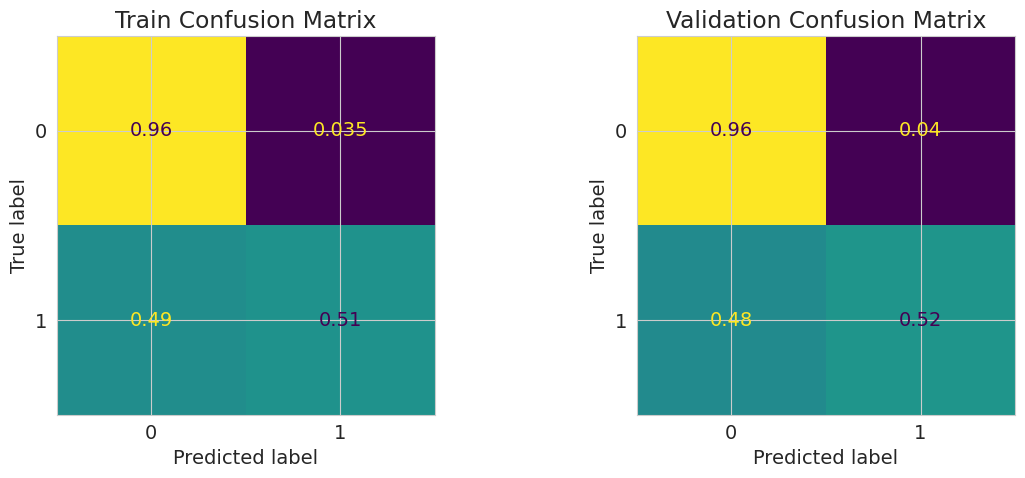

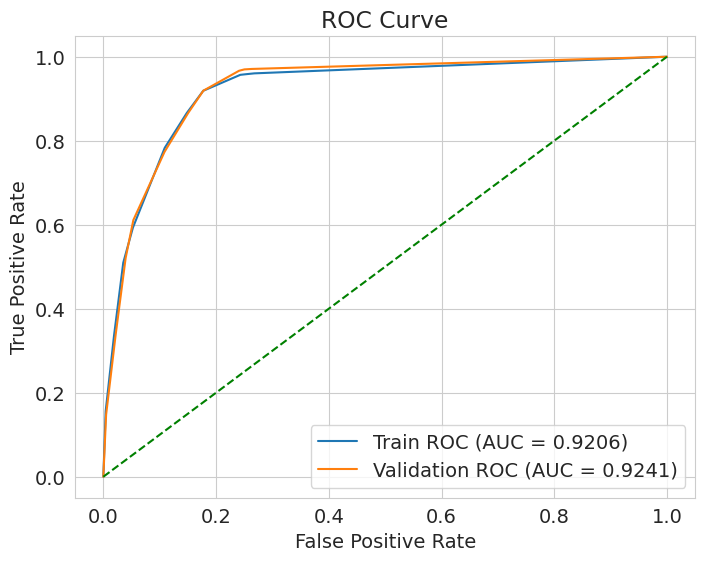

In [79]:
dt_random_search_best = tree_search.best_estimator_

total_report(dt_random_search_best, X_train, X_val, train_targets, val_targets, model_name = 'DecisionTreeClassifier_best_estimator_', best_param = tree_search.best_params_)

**Висновки**:

Менш складне дерево, F1 ≈ 0.57, AUROC ≈ 0.92. Баланс train/val хороший. Може бути використана як просте, стабільне дерево.

##  Aлгоритми бустингу

#### Gradient Boosting model with Randomized Search

In [80]:
from sklearn.ensemble import GradientBoostingClassifier

# Train and evaluate the Gradient Boosting model using Randomized Search for hyperparameter tuning.
gb_model = GradientBoostingClassifier(random_state=42)

# Define the parameter distribution for Randomized Search.
param_dist_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Conduct the Randomized Search with cross-validation to find the best hyperparameters.
random_search_gb = RandomizedSearchCV(gb_model,
                                      param_distributions=param_dist_gb,
                                      n_iter=20,
                                      cv=5,
                                      scoring='f1_macro',
                                      random_state=42,
                                      error_score='raise')

# Fit the randomized search to the training data.
random_search_gb.fit(X_train, y_train)

# Print the optimal hyperparameters found by the Randomized Search for Gradient Boosting.
print(f"Optimal hyperparameters for Gradient Boosting (Randomized Search): {random_search_gb.best_params_}")

Optimal hyperparameters for Gradient Boosting (Randomized Search): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}


F1 score Training: 0.688
F1 score Validation: 0.618


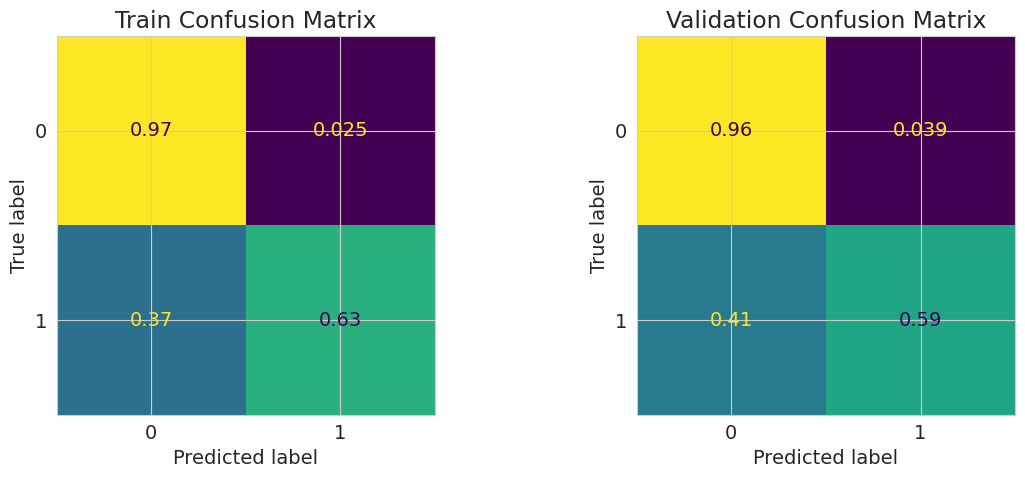

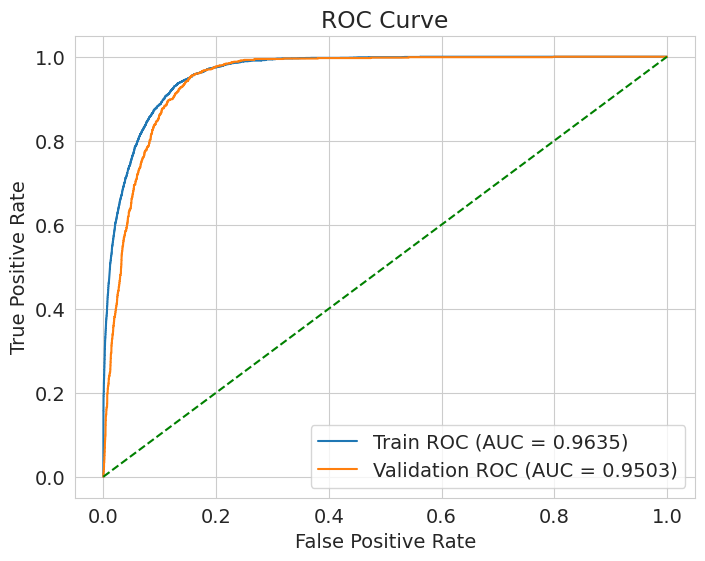

In [82]:
# Створюємо модель з оптимальними параметрами
gb_model_final = GradientBoostingClassifier(**random_search_gb.best_params_, random_state=42)

# Навчаємо на тренувальних даних
gb_model_final.fit(X_train, train_targets)

# Викликаємо total_report
total_report(gb_model_final, X_train, X_val, train_targets, val_targets,  model_name='GradientBoostingClassifier', best_param=random_search_gb.best_params_)

**Висновки:**

F1 train 0.69, val 0.62, AUROC 0.96/0.95. Добре збалансована модель, стабільна, рекомендована до використання. Можна спробувати збільшити n_estimators або оптимізувати learning_rate.

In [83]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [98]:
df_boost = df_log_reg.copy()

In [99]:
train_df, val_df = split_train_val(df_boost, 'y_num')
X_train, train_targets = separate_inputs_targets(train_df, train_df.columns[:-1], train_df.columns[-1])
X_val, val_targets = separate_inputs_targets(val_df, val_df.columns[:-1], val_df.columns[-1])

In [100]:
cat_features = X_train.select_dtypes(include='object').columns
X_train[cat_features] = X_train[cat_features].astype('category')
X_val[cat_features] = X_val[cat_features].astype('category')

### Xgboost

F1 score Training: 0.598
F1 score Validation: 0.579


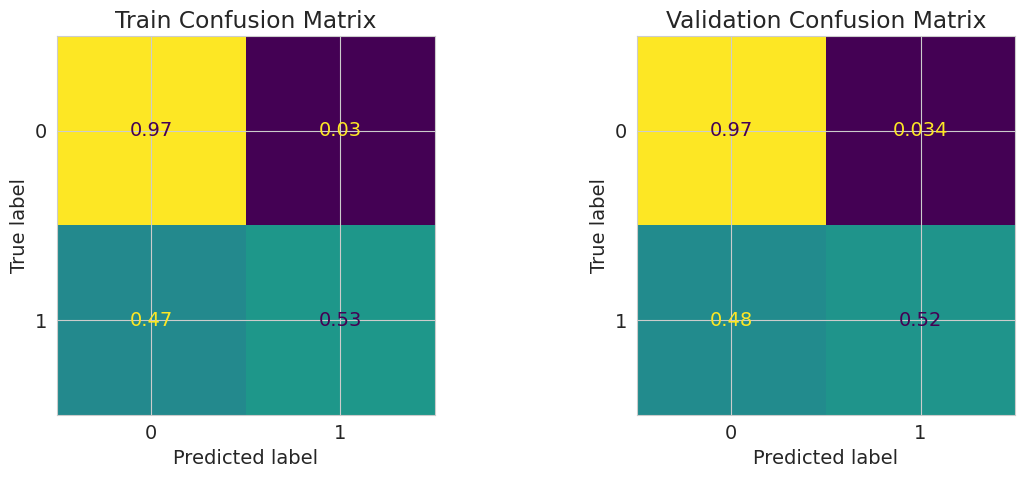

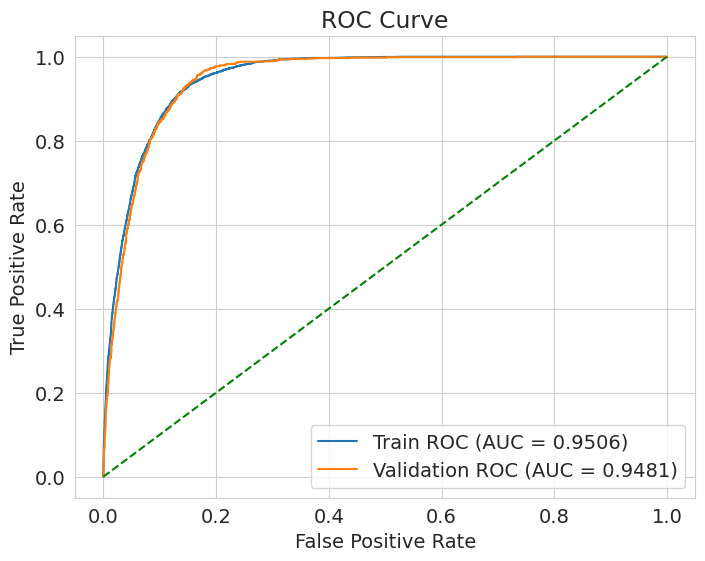

In [111]:
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report,  roc_auc_score

param =     {'max_depth': 3,
          'n_estimators': 30,
    'enable_categorical': True,
                #'device':'cuda'
    }

xgb_clf = XGBClassifier(**param)
xgb_clf.fit(X_train, train_targets)

total_report(xgb_clf, X_train, X_val, train_targets, val_targets, model_name = 'XGBClassifier', best_param = param)

**Висновки:**

F1 ≈ 0.58, AUROC ≈ 0.95. Стабільна, але трохи гірше за Gradient Boosting. Можна тюнити n_estimators та max_depth, потенційно краща продуктивність з більшою кількістю дерев.

#### Oптимальні значення гіперпараметрів XGBoostClassifier

In [112]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score, accuracy_score

random_state_fix = 42

100%|██████████| 50/50 [00:45<00:00,  1.09trial/s, best loss: -0.9526718770643413]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.721289765380893), 'gamma': np.float64(0.20620431009101103), 'learning_rate': np.float64(0.18141560271060198), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 500, 'reg_alpha': np.float64(0.017096689947744492), 'reg_lambda': np.float64(0.9057316356341925), 'subsample': np.float64(0.6162303187347985)}
F1 score Training: 0.971
F1 score Validation: 0.597


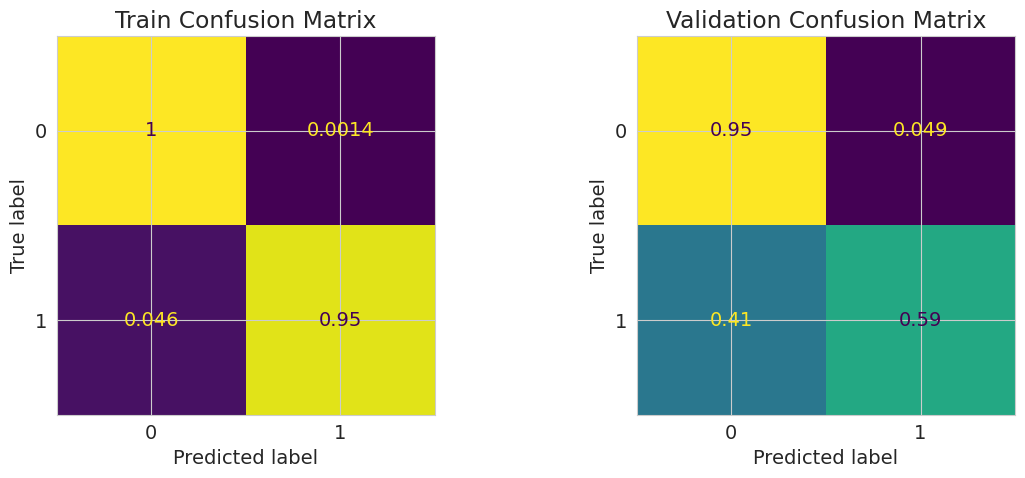

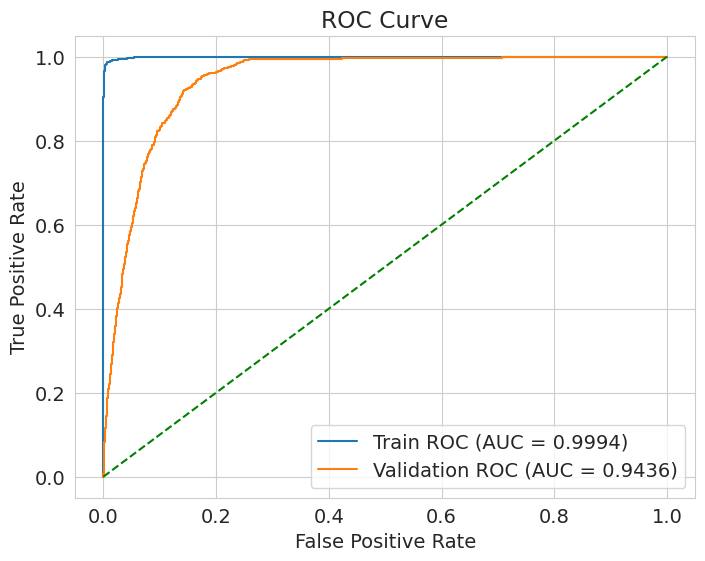

In [113]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        #use_label_encoder=False,
        missing=np.nan,
        #device='cuda',
        early_stopping_rounds=10,
        random_state= random_state_fix,  # <<< Додано для фіксації випадковості моделі
        )

    clf.fit(
        X_train,
        train_targets,
        eval_set=[(X_val, val_targets)],
        verbose=False)
    pred = clf.predict_proba(X_val)[:, 1]
    AUROC = roc_auc_score(val_targets, pred)


    return {'loss': -AUROC, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials, rstate=np.random.default_rng(random_state_fix) )  # max_evals=50 кількість ітерацій


# Перетворення значень гіперпараметрів у кінцеві типи даних
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    #use_label_encoder=False,
    missing=np.nan,
    #device='cuda',
    random_state=random_state_fix,  # <<< Додано для фіксації випадковості моделі
    )

final_clf.fit(X_train, train_targets)

total_report(final_clf, X_train, X_val, train_targets, val_targets, model_name = 'XGBClassifier_hyperopt', best_param = best)

**Висновки:**

Дуже висока F1 на train (0.97), але помітне падіння на val (0.60). Перенавчання, але AUROC на val все ще висока (0.94).

### Lightgbm

In [114]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


F1 score Training: 0.568
F1 score Validation: 0.553


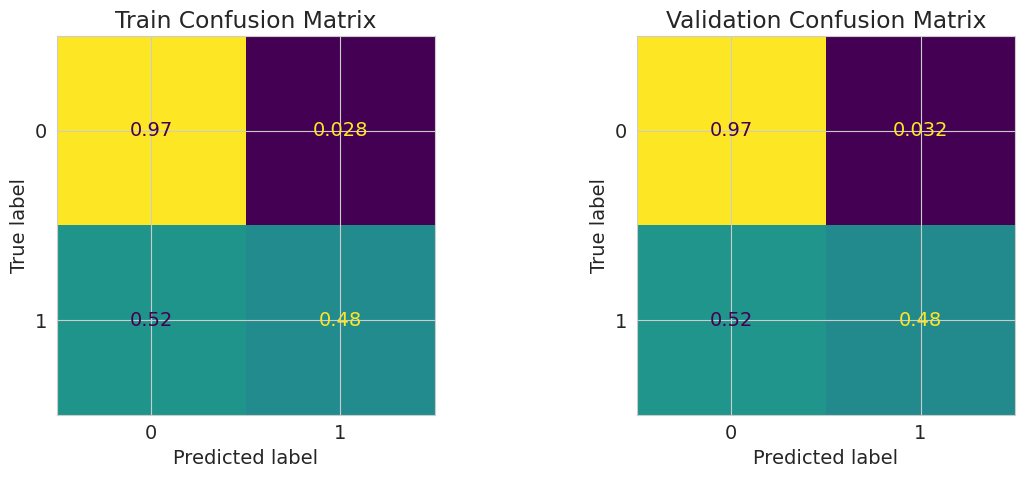

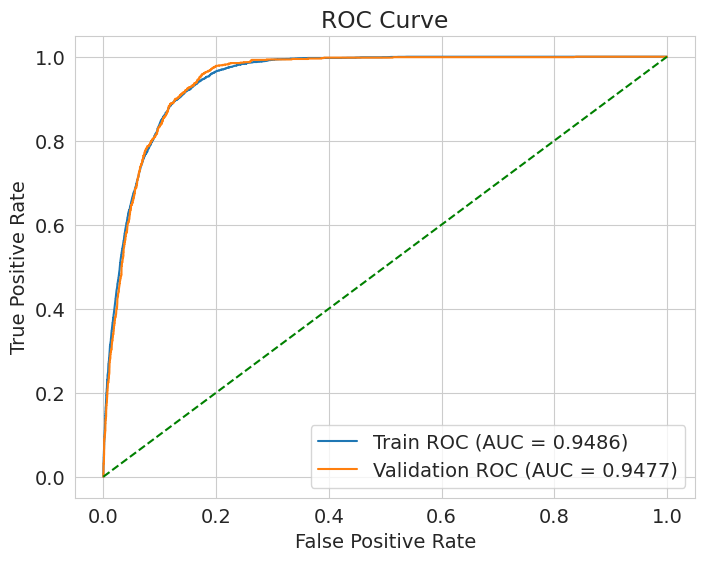

In [115]:
#cat_feature_indexes = [X_train.columns.get_loc(col) for col in cat_features]

param = {'max_depth': 3,
        'n_estimators': 50,
        'learning_rate': 0.1,
        #'cat_feature' : cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    # 'missing': np.nan,  # явне вказування пропущених значень
    # # 'device': 'cuda'  # використовувати GPU для прискорення обчислень
        'verbose': -1}
lgb_clf = lgb.LGBMClassifier(**param)
lgb_clf.fit(X_train, train_targets, eval_set=[(X_val, val_targets)])

total_report(lgb_clf, X_train, X_val, train_targets, val_targets, model_name = 'LGBMClassifier', best_param = param )

**Висновки:**

F1 train ≈ 0.57, F1 val ≈ 0.55 – тренувальна та валідаційна метрики близькі, перенавчання мінімальне. AUROC ≈ 0.948/0.948 – дуже висока та стабільна. Може служити як базова стартова модель або для порівняння.

#### Oптимальні значення гіперпараметрів LightGBM

100%|██████████| 10/10 [00:10<00:00,  1.07s/trial, best loss: -0.952166924414435]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.9494431544017784), 'learning_rate': np.float64(0.014826399805098874), 'max_depth': 10, 'min_child_weight': 1, 'min_split_gain': np.float64(0.018438414694829198), 'n_estimators': 250, 'num_leaves': 68, 'reg_alpha': np.float64(0.43114847346325713), 'reg_lambda': np.float64(0.31459793651174406), 'subsample': np.float64(0.666415739204993)}
F1 score Training: 0.693
F1 score Validation: 0.613


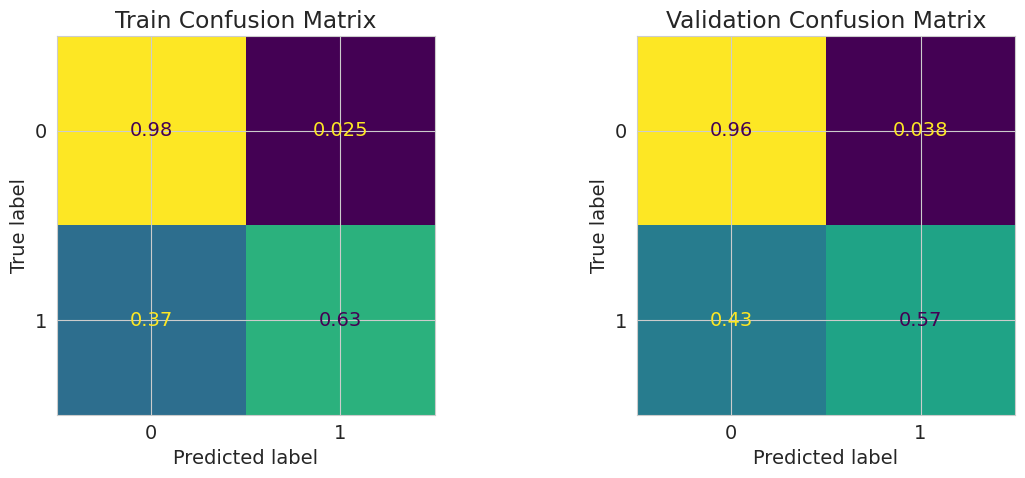

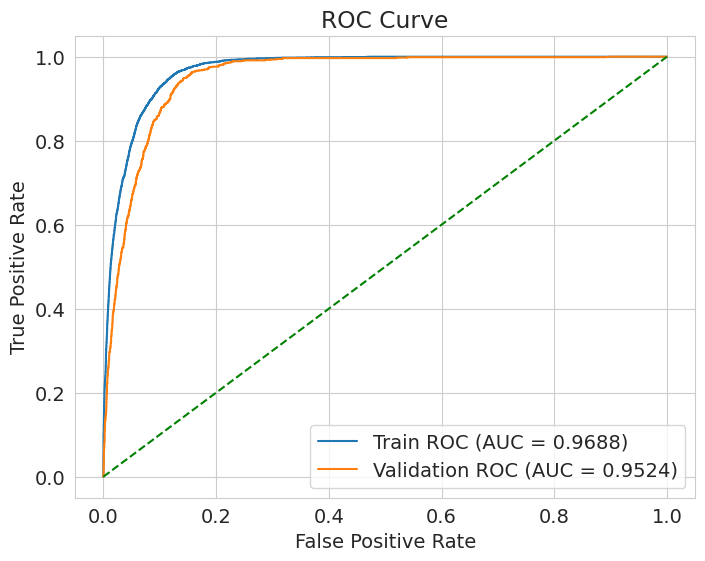

In [116]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        #cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        n_jobs=-1,                 # Використовуємо всі CPU ядра
        random_state=random_state_fix
    )

    # clf.fit(X_train, train_targets, eval_set=[(X_val, val_targets)], early_stopping_rounds=50, verbose=False, n_jobs=-1)
    clf.fit(
        X_train, train_targets,
        eval_set=[(X_val, val_targets)],
        eval_metric="auc",
        #early_stopping_rounds=50,  # Зупинка, якщо якість не росте
        #verbose=False
    )
    pred_proba = clf.predict_proba(X_val)[:, 1]
    AUROC = roc_auc_score(val_targets, pred_proba)

    return {'loss': -AUROC, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb = lgb.LGBMClassifier(
    **best,
    missing=np.nan
)

final_lgb.fit(X_train, train_targets, eval_set=[(X_val, val_targets)],eval_metric="auc")

total_report(final_lgb, X_train, X_val, train_targets, val_targets, model_name = 'LGBMClassifier_hyperopt', best_param = best)

**Висновки:**

F1 train ≈ 0.69, F1 val ≈ 0.61, AUROC ≈ 0.952 на валідації. Значно покращена продуктивність порівняно з базовою моделлю. Добрий кандидат для фінальної моделі. Можна додатково спробувати n_estimators більше або ранню зупинку (early_stopping) для оптимізації.

In [121]:
model_report

,model,f1_train,f1_val,train_auroc,val_auroc,auroc_dif,best_param,info,with_duration
0,LogisticRegression_example,0.516880,0.506545,0.93737,0.93939,-0.00202,"{'solver': 'liblinear', 'random_state': 42}",NaN,1.0
1,LogisticRegression_pipeline,0.520557,0.514286,0.93750,0.93945,-0.00195,"{'solver': 'liblinear', 'random_state': 42}",NaN,1.0
2,LogisticRegression_pipeline_degree_5,0.553273,0.561404,0.94440,0.94540,-0.00100,"{'solver': 'liblinear', 'random_state': 42, 'polinom_degree': 5}",NaN,1.0
3,KNeighborsClassifier,1.000000,0.393443,1.00000,0.75687,0.24313,"{'n_neighbors': 4, 'weights': 'distance'}",NaN,1.0
4,KNeighborsClassifier_knn_best,0.298732,0.267011,0.89080,0.82939,0.06141,{'n_neighbors': 23},NaN,1.0
5,DecisionTreeClassifier,0.785539,0.564103,0.98425,0.84810,0.13615,"{'criterion': 'entropy', 'max_depth': 13, 'random_state': 42}",NaN,1.0
6,DecisionTreeClassifier_best_estimator_,0.570008,0.568235,0.92063,0.92407,-0.00344,"{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_leaf_nodes': 11, 'max_features': None, 'max_depth': 4, 'criterion': 'entropy'}",NaN,1.0
7,GradientBoostingClassifier,0.688017,0.617747,0.96349,0.95029,0.01320,"{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}",NaN,1.0
8,XGBClassifier,0.597982,0.579011,0.95061,0.94808,0.00253,"{'max_depth': 3, 'n_estimators': 30, 'enable_categorical': True}",NaN,1.0
9,XGBClassifier_hyperopt,0.970927,0.597388,0.99943,0.94356,0.05587,"{'colsample_bytree': 0.721289765380893, 'gamma': 0.20620431009101103, 'learning_rate': 0.18141560271060198, 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 500, 'reg_alpha': 0.017096689947744492, 'reg_lambda': 0.9057316356341925, 'subsample': 0.6162303187347985}",NaN,1.0


In [122]:
model_report['info'] = [
    "Модель стабільна (train ≈ val). Може бути використана як стартова модель, але можна покращити через розширення ознак або поліноміальні взаємодії.",
    "Pipeline з препроцесінгом дає невелике покращення F1. AUROC стабільний. Варто використовувати як базову, особливо якщо дані різнорідні (категоріальні + числові).",
    "Поліноміальні ознаки (степінь 5) дають найвищий F1 серед логістичних моделей (0.56). AUROC дуже високий. Гарна модель, але варто перевірити перенавчання на нових даних.",
    "Дуже висока F1 на train (1.0), але сильне падіння на val (0.39). Перенавчання. Використовувати не рекомендую без регуляризації або зміни кількості сусідів.",
    "Більш “помірна” конфігурація KNN. F1 низький (0.27). Недостатньо ефективна. Можна спробувати оптимізацію weights, metric та масштабування ознак.",
    "F1 train 0.79 vs val 0.56, AUROC train 0.98 vs val 0.85. Перенавчання, але модель дає непогану AUROC. Варто обмежити max_depth або min_samples_leaf, або використовувати ансамблі дерев.",
    "Менш складне дерево, F1 ≈ 0.57, AUROC ≈ 0.92. Баланс train/val хороший. Може бути використана як просте, стабільне дерево.",
    "F1 train 0.69, val 0.62, AUROC 0.96/0.95. Добре збалансована модель, стабільна, рекомендована до використання. Можна спробувати збільшити n_estimators або оптимізувати learning_rate.",
    "F1 ≈ 0.58, AUROC ≈ 0.95. Стабільна, але трохи гірше за Gradient Boosting. Можна тюнити n_estimators та max_depth, потенційно краща продуктивність з більшою кількістю дерев.",
    "Дуже висока F1 на train (0.97), але помітне падіння на val (0.60). Перенавчання, але AUROC на val все ще висока (0.94). Потенційно краща продуктивність з регуляризацією (subsample, colsample_bytree) або ранньою зупинкою.",
    "Тренувальна та валідаційна метрики близькі, перенавчання мінімальне. AUROC ≈ 0.948/0.948 – дуже висока та стабільна. Може служити як базова стартова модель або для порівняння.",
    "Значно покращена продуктивність порівняно з базовою моделлю. Добрий кандидат для фінальної моделі. Можна додатково спробувати n_estimators більше або ранню зупинку (early_stopping) для оптимізації."
]

In [127]:
#model_report = model_report.drop(index = [12])
#model_report.sort_values('auroc_dif', ascending = True)

In [126]:
model_report

,model,f1_train,f1_val,train_auroc,val_auroc,auroc_dif,best_param,info,with_duration
0,LogisticRegression_example,0.516880,0.506545,0.93737,0.93939,-0.00202,"{'solver': 'liblinear', 'random_state': 42}","Модель стабільна (train ≈ val). Може бути використана як стартова модель, але можна покращити через розширення ознак або поліноміальні взаємодії.",1.0
1,LogisticRegression_pipeline,0.520557,0.514286,0.93750,0.93945,-0.00195,"{'solver': 'liblinear', 'random_state': 42}","Pipeline з препроцесінгом дає невелике покращення F1. AUROC стабільний. Варто використовувати як базову, особливо якщо дані різнорідні (категоріальні + числові).",1.0
2,LogisticRegression_pipeline_degree_5,0.553273,0.561404,0.94440,0.94540,-0.00100,"{'solver': 'liblinear', 'random_state': 42, 'polinom_degree': 5}","Поліноміальні ознаки (степінь 5) дають найвищий F1 серед логістичних моделей (0.56). AUROC дуже високий. Гарна модель, але варто перевірити перенавчання на нових даних.",1.0
3,KNeighborsClassifier,1.000000,0.393443,1.00000,0.75687,0.24313,"{'n_neighbors': 4, 'weights': 'distance'}","Дуже висока F1 на train (1.0), але сильне падіння на val (0.39). Перенавчання. Використовувати не рекомендую без регуляризації або зміни кількості сусідів.",1.0
4,KNeighborsClassifier_knn_best,0.298732,0.267011,0.89080,0.82939,0.06141,{'n_neighbors': 23},"Більш “помірна” конфігурація KNN. F1 низький (0.27). Недостатньо ефективна. Можна спробувати оптимізацію weights, metric та масштабування ознак.",1.0
5,DecisionTreeClassifier,0.785539,0.564103,0.98425,0.84810,0.13615,"{'criterion': 'entropy', 'max_depth': 13, 'random_state': 42}","F1 train 0.79 vs val 0.56, AUROC train 0.98 vs val 0.85. Перенавчання, але модель дає непогану AUROC. Варто обмежити max_depth або min_samples_leaf, або використовувати ансамблі дерев.",1.0
6,DecisionTreeClassifier_best_estimator_,0.570008,0.568235,0.92063,0.92407,-0.00344,"{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_leaf_nodes': 11, 'max_features': None, 'max_depth': 4, 'criterion': 'entropy'}","Менш складне дерево, F1 ≈ 0.57, AUROC ≈ 0.92. Баланс train/val хороший. Може бути використана як просте, стабільне дерево.",1.0
7,GradientBoostingClassifier,0.688017,0.617747,0.96349,0.95029,0.01320,"{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}","F1 train 0.69, val 0.62, AUROC 0.96/0.95. Добре збалансована модель, стабільна, рекомендована до використання. Можна спробувати збільшити n_estimators або оптимізувати learning_rate.",1.0
8,XGBClassifier,0.597982,0.579011,0.95061,0.94808,0.00253,"{'max_depth': 3, 'n_estimators': 30, 'enable_categorical': True}","F1 ≈ 0.58, AUROC ≈ 0.95. Стабільна, але трохи гірше за Gradient Boosting. Можна тюнити n_estimators та max_depth, потенційно краща продуктивність з більшою кількістю дерев.",1.0
9,XGBClassifier_hyperopt,0.970927,0.597388,0.99943,0.94356,0.05587,"{'colsample_bytree': 0.721289765380893, 'gamma': 0.20620431009101103, 'learning_rate': 0.18141560271060198, 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 500, 'reg_alpha': 0.017096689947744492, 'reg_lambda': 0.9057316356341925, 'subsample': 0.6162303187347985}","Дуже висока F1 на train (0.97), але помітне падіння на val (0.60). Перенавчання, але AUROC на val все ще висока (0.94). Потенційно краща продуктивність з регуляризацією (subsample, colsample_bytree) або ранньою зупинкою.",1.0


**Висновок:**

З урахуванням F1 на валідації, AUROC на валідації та перенавчання, найбільш збалансовані і продуктивні моделі:

- GradientBoostingClassifier

F1 val ≈ 0.62, AUROC val ≈ 0.95

Баланс між train/val хороший, невелике перенавчання.

- LGBMClassifier_hyperopt

F1 val ≈ 0.61, AUROC val ≈ 0.95

Стабільна і добре оптимізована модель.

In [128]:
model_report.to_csv('model_report_with_duration_A.csv', index=False)